<a href="https://colab.research.google.com/github/Jeshurun-B/EMA-optimizer-pipeline-v2/blob/main/coolab_notebooks/week2_logistic_regression%20v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📅 Week 2 — Logistic Regression Deep Dive
**EMA Crossover ML Project | 10-Week Curriculum**
**Date:** June 8, 2026

---

### What This Week Is About
Week 1 proved that linear rEgression cannot reliably predict signal quality on this data — assumption violations were widespread, and performance ranged from decent (BTC/ETH with Target 3, short side) to near-zero (global LONG with the hard-gate Control target). This week you pivot to **binary classification**: instead of predicting a continuous quality score, you predict whether a signal is *good enough to trade* (1) or not (0). You will define three candidate binary targets, choose the one most aligned with your trading goals, and build a full Logistic Regression pipeline covering the mathematics, probability output, confusion matrix, regularisation, and threshold tuning. This is the model every more powerful algorithm (trees, boosting, neural nets) will be benchmarked against.

**By end of week you will have:**
- A justified binary target with documented class balance
- Trained Logistic Regression baselines for both LONG and SHORT
- Confusion matrix, ROC curve, and Precision-Recall curve interpreted in trading terms
- A regularisation sweep (C = [0.01, 0.1, 1, 10, 100]) with a chosen operating threshold
- Odds ratios for the top features explaining *why* the model flags a signal as good


## Section 0 — Environment Setup

Run this first every session.

In [ ]:
# Install required libraries
!pip install -q supabase scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.9 MB/s eta 0:00:00


In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from supabase import create_client
from google.colab import userdata

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Environment ready')


Environment ready


## Section 1 — Connect to Both Databases

Same dual-connection pattern from Week 1. Run every session.

In [ ]:
# ============================================================
# CONNECT TO MAIN DATABASE
# ============================================================
try:
    main_client = create_client(userdata.get('SUPABASE_URL'), userdata.get('SUPABASE_KEY'))
    print('Main database connected')
except Exception as e:
    print(f'Main connection failed: {e}')


Main database connected


In [ ]:
# ============================================================
# CONNECT TO ANALYTICS DATABASE
# ============================================================
try:
    analytics_client = create_client(
        userdata.get('ANALYTICS_SUPABASE_URL'),
        userdata.get('ANALYTICS_SUPABASE_KEY')
    )
    print('Analytics database connected')
except Exception as e:
    print(f'Analytics connection failed: {e}')


Analytics database connected


## Section 2 — Fetch Data and Merge

Fetch both tables, parse datetime columns with `utc=True`, inner-join on `(symbol, checked_at_utc)`. Identical to Week 1.

In [ ]:
# ============================================================
# FETCH: Main signals table
# ============================================================
response_main = main_client.table('signals').select('*').eq('status', 'analyzed').execute()
df_main = pd.DataFrame(response_main.data)

for col in ['checked_at_utc', 'time_of_max_price', 'time_of_min_price']:
    if col in df_main.columns:
        df_main[col] = pd.to_datetime(df_main[col], utc=True, errors='coerce')

df_main = df_main.sort_values('checked_at_utc').reset_index(drop=True)
print(f'Main signals: {len(df_main):,} rows | {df_main.shape[1]} columns')
print(f'Range: {df_main["checked_at_utc"].min().date()} to {df_main["checked_at_utc"].max().date()}')
print(f'Signal split: {df_main["signal"].value_counts().to_dict()}')


Main signals: 6,844 rows | 48 columns
Range: 2025-10-03 to 2026-06-17
Signal split: {'LONG': 3422, 'SHORT': 3422}


In [ ]:
# ============================================================
# FETCH: Analytics table
# ============================================================
response_analytics = analytics_client.table('crossover_analytics').select('*').execute()
df_analytics = pd.DataFrame(response_analytics.data)

for col in ['crossover_utc', 'next_crossover_utc', 'optimal_entry_utc']:
    if col in df_analytics.columns:
        df_analytics[col] = pd.to_datetime(df_analytics[col], utc=True, errors='coerce')

df_analytics = df_analytics.sort_values('crossover_utc').reset_index(drop=True)
print(f'Analytics: {len(df_analytics):,} rows | {df_analytics.shape[1]} columns')


Analytics: 7,488 rows | 14 columns


In [ ]:
# ============================================================
# MERGE: inner join on (symbol, checked_at_utc)
# ============================================================
df_analytics_renamed = df_analytics.rename(columns={'crossover_utc': 'checked_at_utc'})
df = pd.merge(df_main, df_analytics_renamed, how='inner', on=['checked_at_utc', 'symbol'])

main_lost      = len(df_main) - len(df)
analytics_lost = len(df_analytics) - len(df)

print(f'Merged dataset: {len(df):,} rows | {df.shape[1]} columns')
print(f'Lost from main (no analytics match): {main_lost:,} ({main_lost/len(df_main)*100:.1f}%)')
print(f'Lost from analytics (no main match): {analytics_lost:,}')
print()
print('Records per symbol:')
print(df['symbol'].value_counts())


Merged dataset: 6,844 rows | 60 columns
Lost from main (no analytics match): 0 (0.0%)
Lost from analytics (no main match): 644

Records per symbol:
symbol
ETHUSDT     1424
SOLUSDT     1379
XRPUSDT     1357
BTCUSDT     1353
DOGEUSDT    1331
Name: count, dtype: int64


## Section 3 — Apply Signal Quality Columns

Your **evolved 4-track target system** from Week 1. Applied every week after merge.

| Column | Range | Role this week |
|--------|-------|----------------|
| `T1_Pure_Continuous` | 0–10 | Smooth linear R:R + time decay. No hard gates. |
| `T2_Soft_Floor` | 0–10 | Sub-0.25% risk trades penalised 90%, not zeroed. |
| `T3_Assumption_Penalty` | 0–10 | Subtractive penalties for volume, HTF trend, adverse excursion. |
| `T4_Control_Punished` | 0–10 | Original hard-gate baseline (the lazy model trap). |
| `target_special` | 0–10 | **Production target.** Row-wise min of T1–T3. |
| `Optimum_entry` | float | **Candle-based timing.** 15-min candles from crossover to optimal entry. |

> `Optimum_entry` was refactored in Week 1 from a categorical (1–6) to a **continuous candle count** (time delta between `optimal_entry_utc` and `checked_at_utc` divided by 15 minutes). This more precisely reflects real entry timing structure.


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# SIGNAL QUALITY SCORING MODULE (Week 1 final version)
# ============================================================

def get_time_decay_score(candles):
    if candles <= 20:
        return 1.0
    elif candles <= 100:
        t = (candles - 20) / 80
        return np.exp(-3.5 * t)
    elif candles <= 400:
        base = np.exp(-3.5)
        t = (candles - 100) / 300
        return base * np.exp(-4 * t)
    else:
        return 0.0

def time_cutoff(candles):
    if candles <= 20:   return 1.0
    elif candles <= 40: return 0.5
    else:               return 0

def calculate_four_target_scores(row):
    is_long = str(row['signal_x']).upper() == 'LONG'
    if is_long:
        p, r = float(row['max_move_up_pct']), float(row['max_move_down_pct'])
        candles_to_peak_profit = int(row['candles_to_max_price'])
        candles_to_max_pain    = int(row['candles_to_min_price'])
        is_btc  = bool(row['btc_trend_bias'])
        is_1d   = bool(row['htf_1d_bias'])
        is_4h   = bool(row['htf_4h_bias'])
    else:
        p, r = float(row['max_move_down_pct']), float(row['max_move_up_pct'])
        candles_to_peak_profit = int(row['candles_to_min_price'])
        candles_to_max_pain    = int(row['candles_to_max_price'])
        is_btc  = not bool(row['btc_trend_bias'])
        is_1d   = not bool(row['htf_1d_bias'])
        is_4h   = not bool(row['htf_4h_bias'])

    r_safe = 0.01 if r <= 0 else r
    current_rr  = p / r_safe
    t_factor    = get_time_decay_score(candles_to_peak_profit)
    base        = round(min(5.0, current_rr) + 5.0 * t_factor, 2)

    t1 = base

    if candles_to_max_pain < candles_to_peak_profit and r >= p:
        t2 = round(base * 0.2, 2)
    elif r < 0.25:
        t2 = round(base * 0.1, 2)
    else:
        t2 = base

    pen = base
    if 'volume_ratio' in row and float(row['volume_ratio']) < 1.0: pen -= 0.8
    if not is_btc:  pen -= 0.5
    if not is_1d:   pen -= 1.0
    if not is_4h:   pen -= 1.2
    if candles_to_max_pain < candles_to_peak_profit and r > 0.75 * p: pen -= 0.8
    t3 = round(max(0, pen), 2)

    if r < 0.25 or (candles_to_max_pain < candles_to_peak_profit and r >= p):
        t4 = 0.0
    else:
        if current_rr >= 4:              rr_p = 5.0
        elif current_rr >= 1.5:          rr_p = current_rr
        elif 1.0 <= current_rr < 1.5:   rr_p = (current_rr**7) / (1.5**6)
        else:                             rr_p = 0.0
        t_s = time_cutoff(candles_to_peak_profit)
        t4  = round(5.0 * t_s + rr_p, 2) if rr_p > 0 else 0.0

    return t1, t2, t3, t4


def optimal_entry_candles(row):
    """Returns 15-min candles from crossover to optimal entry. 0 = immediate entry."""
    try:
        if pd.isnull(row['optimal_entry_utc']) or pd.isnull(row['checked_at_utc']):
            return 0.0
        diff = row['optimal_entry_utc'] - row['checked_at_utc']
        return float(diff.total_seconds() / 60 / 15)
    except Exception:
        return 0.0


# Apply
target_cols = ['T1_Pure_Continuous', 'T2_Soft_Floor', 'T3_Assumption_Penalty', 'T4_Control_Punished']
df[target_cols] = df.apply(lambda r: pd.Series(calculate_four_target_scores(r)), axis=1)
df['target_special'] = df[target_cols[:3]].min(axis=1)
df['Optimum_entry']  = df.apply(optimal_entry_candles, axis=1)

print('All quality columns applied.')
print('\n--- % scoring above 5.0 ---')
for col in target_cols + ['target_special']:
    print(f'  {col:<28} -> {(df[col] > 5).mean()*100:.1f}%')
print(f'\n  Optimum_entry median: {df["Optimum_entry"].median():.1f} candles | mean: {df["Optimum_entry"].mean():.1f}')


All quality columns applied.

--- % scoring above 5.0 ---
  T1_Pure_Continuous           -> 98.6%
  T2_Soft_Floor                -> 78.2%
  T3_Assumption_Penalty        -> 36.7%
  T4_Control_Punished          -> 28.8%
  target_special               -> 27.0%

  Optimum_entry median: 0.0 candles | mean: 1.0


In [ ]:
df[['checked_at_utc','symbol','signal_x', 'max_move_up_pct' , 'max_move_down_pct' , 'mfe_percent' , 'mae_percent','optimal_entry', 'optimal_entry_utc']].tail(20)

,checked_at_utc,symbol,signal_x,max_move_up_pct,max_move_down_pct,mfe_percent,mae_percent,optimal_entry,optimal_entry_utc
6824,2026-06-17 02:15:00+00:00,XRPUSDT,LONG,0.2121,1.0688,0.21,-0.35,1.22140,2026-06-17 02:15:00+00:00
6825,2026-06-17 03:15:00+00:00,ETHUSDT,SHORT,0.6058,0.1837,0.18,-0.04,1791.68000,2026-06-17 03:15:00+00:00
6826,2026-06-17 03:15:00+00:00,XRPUSDT,SHORT,0.6420,0.1893,0.19,-0.07,1.21570,2026-06-17 03:15:00+00:00
6827,2026-06-17 03:45:00+00:00,SOLUSDT,SHORT,0.5836,0.2172,0.22,-0.08,73.74000,2026-06-17 03:45:00+00:00
6828,2026-06-17 04:45:00+00:00,SOLUSDT,LONG,0.3792,0.3522,0.38,-0.05,73.79000,2026-06-17 04:45:00+00:00
6829,2026-06-17 05:00:00+00:00,SOLUSDT,SHORT,0.5434,2.7442,2.74,-0.54,74.01000,2026-06-17 05:00:00+00:00
6830,2026-06-17 05:30:00+00:00,XRPUSDT,LONG,0.1065,0.6064,0.11,-0.21,1.21770,2026-06-17 05:30:00+00:00
6831,2026-06-17 05:45:00+00:00,DOGEUSDT,SHORT,0.3204,2.1968,2.20,-0.32,0.08768,2026-06-17 05:45:00+00:00
6832,2026-06-17 06:00:00+00:00,ETHUSDT,LONG,0.0936,0.3848,0.02,-0.16,1792.69000,2026-06-17 06:00:00+00:00
6833,2026-06-17 06:15:00+00:00,XRPUSDT,SHORT,0.5934,2.0605,2.06,-0.59,1.22050,2026-06-17 06:15:00+00:00


## Section 4 — Feature Sets

Your Week 1 MI analysis produced two separate 15-feature matrices. These are your inputs for all models this week.


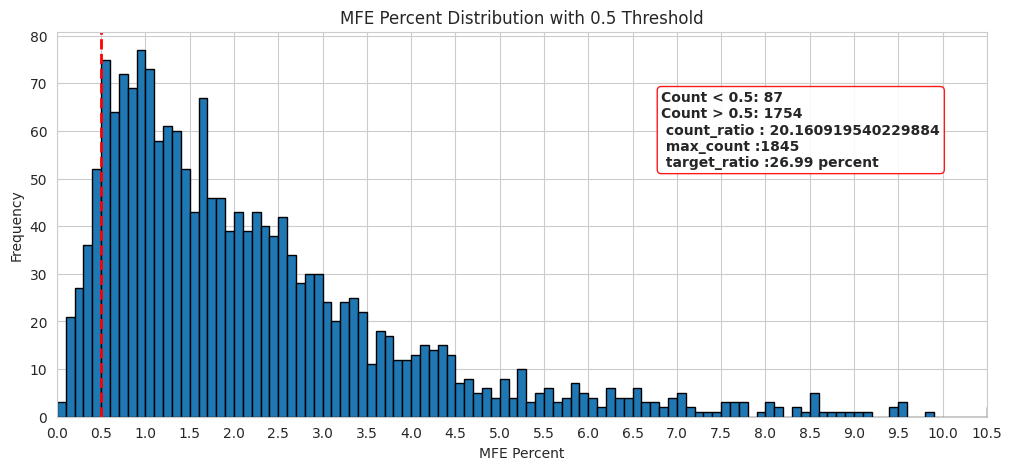

In [ ]:
# list = []
# for i in range (0,10):
#     dd = df[(df['T3_Assumption_Penalty'] > i ) & (df['mfe_percent'] >0.3)]['T3_Assumption_Penalty']
#     lenght = len(dd)
#     list.append(lenght)
# plt.plot(range(0,10),list)



# 1. Filter the data (ensuring we don't pre-filter out values <= 0.5 so we can count them!)
filtered_data = df[(df['T3_Assumption_Penalty'] > 5.5)]['mfe_percent']

# 2. Calculate the exact counts relative to the 0.5 threshold
max_count =  (df['T3_Assumption_Penalty'] > 5.5).sum()
count_below_05 = (filtered_data < 0.4).sum()
count_above_05 = (filtered_data > 0.4).sum()
count_ratio = (count_above_05/count_below_05)
target_ratio = f'{round((max_count / (df['T3_Assumption_Penalty'] > 0).sum())*100 , 2)} percent'

# 3. BINS: High-resolution 0.1 intervals from 0 to 20
bin_edges = np.arange(0, 20.11, 0.1)

# 4. Plot the histogram
plt.hist(filtered_data, bins=bin_edges, edgecolor='black')

# 5. Add a prominent red vertical line at x = 0.5
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')

# 6. Display the counts inside a clean text box in the upper right
# Using transform=plt.gca().transAxes keeps the box in place regardless of data scale
text_info = f'Count < 0.5: {count_below_05}\nCount > 0.5: {count_above_05}\n count_ratio : {count_ratio}\n max_count :{max_count}\n target_ratio :{target_ratio}'
box_properties = dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.9)

plt.gca().text(0.65,0.65 , text_info, transform=plt.gca().transAxes,
                fontsize=10, fontweight='bold', bbox=box_properties)

# 7. Strictly lock the visual x-axis limits from 0 to 20
plt.xlim(0, 10)

# 8. TICKS: X-axis labels at 0.5 intervals
tick_positions = np.arange(0, 10.51, 0.5)
plt.xticks(tick_positions)

# 9. Add updated descriptive labels
plt.title('MFE Percent Distribution with 0.5 Threshold')
plt.xlabel('MFE Percent')
plt.ylabel('Frequency')

# Save the plot safely without text truncation
plt.savefig('histogram_with_threshold.png', bbox_inches='tight')

In [ ]:
# ============================================================
# FEATURE SET DEFINITIONS (from Week 1 MI analysis)
# ============================================================

FEATURES_ALL = [
    'ema_fast_ltf', 'ema_slow_ltf', 'ema_fast_slope', 'ema_slow_slope',
    'ema_separation', 'price_above_both_emas', 'crossover_candle_strength',
    'adx_ltf', 'adx_slope', 'adx_4h', 'macd_histogram_ltf', 'macd_histogram_4h',
    'htf_4h_bias', 'htf_1d_bias', 'ema_separation_4h', 'rsi_4h',
    'rsi_ltf', 'roc_ltf', 'atr_ltf', 'atr_pct', 'bb_width_ltf', 'price_to_atr',
    'volume_ratio', 'volume_trend', 'crossover_volume_ratio',
    'fear_greed_index', 'btc_trend_bias', 'hour_of_day', 'day_of_week',
    'swing_high', 'swing_low', 'atr_stop_distance', 'signal_gap_hours'
]

FEATURES_LONG_MI = [
    'volume_ratio', 'btc_trend_bias', 'rsi_4h', 'htf_4h_bias',
    'ema_separation_4h', 'ema_fast_slope', 'ema_slow_slope', 'price_to_atr',
    'atr_pct', 'bb_width_ltf', 'volume_trend', 'htf_1d_bias',
    'atr_ltf', 'macd_histogram_ltf', 'rsi_ltf'
]

FEATURES_SHORT_MI = [
    'rsi_4h', 'htf_4h_bias', 'ema_separation_4h', 'btc_trend_bias',
    'ema_fast_slope', 'ema_slow_slope', 'atr_pct', 'htf_1d_bias',
    'price_to_atr', 'crossover_volume_ratio', 'volume_ratio', 'roc_ltf',
    'bb_width_ltf', 'atr_stop_distance', 'atr_ltf'
]

TARGET_CONTINUOUS = 'T3_Assumption_Penalty'  # best performing  production target from Week 1

print(f'FEATURES_ALL:      {len(FEATURES_ALL)} features')
print(f'FEATURES_LONG_MI:  {len(FEATURES_LONG_MI)} features')
print(f'FEATURES_SHORT_MI: {len(FEATURES_SHORT_MI)} features')


FEATURES_ALL:      33 features
FEATURES_LONG_MI:  15 features
FEATURES_SHORT_MI: 15 features


## Section 5 — Binary Target Definition (Monday)

**The most important decision of Week 2.** You are switching from regression to classification. You need a binary label: `1 = good signal`, `0 = bad signal`.

Three candidates:
- **Definition A** — `target_special >= threshold` (your own quality system)
- **Definition B** — `pnl_percent > 0` (did the trade profit?)
- **Definition C** — `mfe_percent >= X AND mae_percent >= -Y` (R:R filter)

For each, check **class balance** (% positives). Aim for 30–70%. Outside that range you need explicit imbalance handling.

> **Bayes theorem connection:** The proportion of positives IS your prior P(good signal). Before seeing any features, this is the baseline the model must beat.


In [ ]:
# ============================================================
# DEFINITION A: target_special >= threshold
# ============================================================
# TODO: Choose a starting threshold. Try 3.0, 5.0, 7.0 and compare class balance.

THRESHOLD_A = 5.3  # TODO: set this, e.g. 5.0

df['classification_target_1'] = ((df['T3_Assumption_Penalty'] > THRESHOLD_A) & (df['mfe_percent'] > 0.5)).astype(int)

# TODO: Print:
#   - Total rows, count of 1s and 0s

#   - % positive overall

#   - % positive for LONG vs SHORT separately
display(df.groupby('signal_x')['classification_target_1'].value_counts(normalize = True)*100)
print(f'Definition A: target_special >= {THRESHOLD_A}')

display(df['classification_target_1'].value_counts(normalize = False))


display(df['mfe_percent'].describe(percentiles = [0.2,0.3,0.9,0.96, 0.97, 0.98, 0.99]))

signal_x  classification_target_1
LONG      0                          78.930450
          1                          21.069550
SHORT     0                          67.475161
          1                          32.524839
Name: proportion, dtype: float64

Definition A: target_special >= 5.3


,count
classification_target_1,
0,5010
1,1834


,mfe_percent
count,6844.000000
mean,1.243797
std,2.128816
min,0.000000
20%,0.160000
30%,0.250000
50%,0.550000
90%,3.100000
96%,5.210000
97%,5.957100


In [ ]:
# Quick inspection array to find your optimal joint filter matrix
for mfe_test in [0.5, 0.9, 1.2, 1.5]:
    for t3_test in [3.0, 4.5, 5.5, 7.0]:
        matching = len(df[
            ((df['mfe_percent'] ) > mfe_test) &
            (df['T3_Assumption_Penalty'] > t3_test)
        ])
        print(f"Filter Matrix -> MFE > {mfe_test:.1f} AND T3 > {t3_test:.1f} | Retained Trades: {matching}")

Filter Matrix -> MFE > 0.5 AND T3 > 3.0 | Retained Trades: 3116
Filter Matrix -> MFE > 0.5 AND T3 > 4.5 | Retained Trades: 2373
Filter Matrix -> MFE > 0.5 AND T3 > 5.5 | Retained Trades: 1700
Filter Matrix -> MFE > 0.5 AND T3 > 7.0 | Retained Trades: 878
Filter Matrix -> MFE > 0.9 AND T3 > 3.0 | Retained Trades: 2257
Filter Matrix -> MFE > 0.9 AND T3 > 4.5 | Retained Trades: 1831
Filter Matrix -> MFE > 0.9 AND T3 > 5.5 | Retained Trades: 1412
Filter Matrix -> MFE > 0.9 AND T3 > 7.0 | Retained Trades: 784
Filter Matrix -> MFE > 1.2 AND T3 > 3.0 | Retained Trades: 1862
Filter Matrix -> MFE > 1.2 AND T3 > 4.5 | Retained Trades: 1537
Filter Matrix -> MFE > 1.2 AND T3 > 5.5 | Retained Trades: 1218
Filter Matrix -> MFE > 1.2 AND T3 > 7.0 | Retained Trades: 709
Filter Matrix -> MFE > 1.5 AND T3 > 3.0 | Retained Trades: 1552
Filter Matrix -> MFE > 1.5 AND T3 > 4.5 | Retained Trades: 1294
Filter Matrix -> MFE > 1.5 AND T3 > 5.5 | Retained Trades: 1040
Filter Matrix -> MFE > 1.5 AND T3 > 7.0 | R

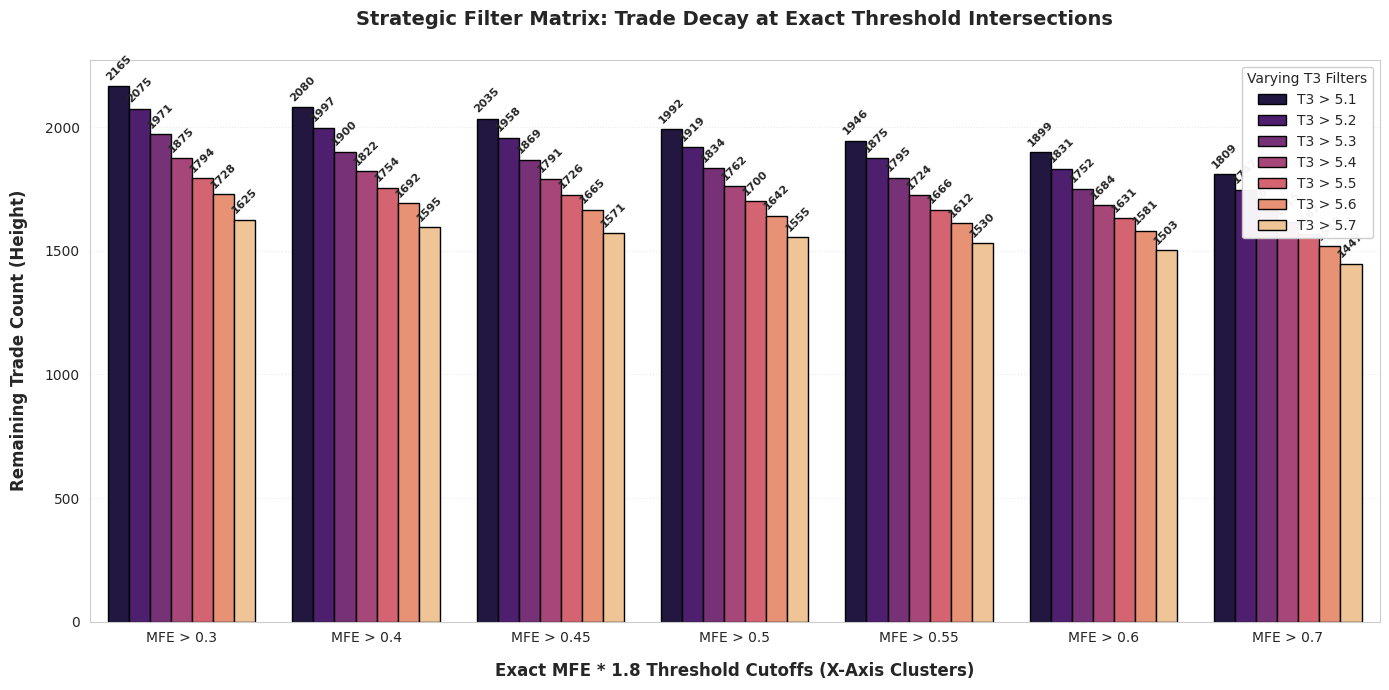

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the exact, granular threshold points you want to test
mfe_points = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]
t3_variants = [5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7]

# 2. Build the matrix by computing the exact intersection counts
matrix_rows = []
for mfe_th in mfe_points:
    for t3_th in t3_variants:
        # Count trades matching BOTH criteria simultaneously
        count = len(df[
            ((df['mfe_percent'] ) > mfe_th) &
            (df['T3_Assumption_Penalty'] > t3_th)
        ])
        matrix_rows.append({
            'MFE_Threshold': f'MFE > {mfe_th}',
            'T3_Threshold': f'T3 > {t3_th}',
            'Trade_Count': count
        })

# Convert to DataFrame for plotting
grid_df = pd.DataFrame(matrix_rows)

# 3. Plot the precise clustered bar chart
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=grid_df,
    x='MFE_Threshold',
    y='Trade_Count',
    hue='T3_Threshold',
    palette='magma',  # Gives a distinct contrast variation for the T3 lines
    edgecolor='black',
    ax=ax
)

# 4. Add the exact numbers on top of every single bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=8,
        fontweight='bold',
        rotation=45  # Rotated slightly so numbers don't collide if counts are dense
    )

# 5. Presentation formatting
ax.set_xlabel('Exact MFE * 1.8 Threshold Cutoffs (X-Axis Clusters)', fontsize=12, fontweight='bold', labelpad=12)
ax.set_ylabel('Remaining Trade Count (Height)', fontsize=12, fontweight='bold', labelpad=12)
ax.set_title('Strategic Filter Matrix: Trade Decay at Exact Threshold Intersections', pad=25, fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle=':', alpha=0.4)

# Place legend cleanly
ax.legend(title='Varying T3 Filters', loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

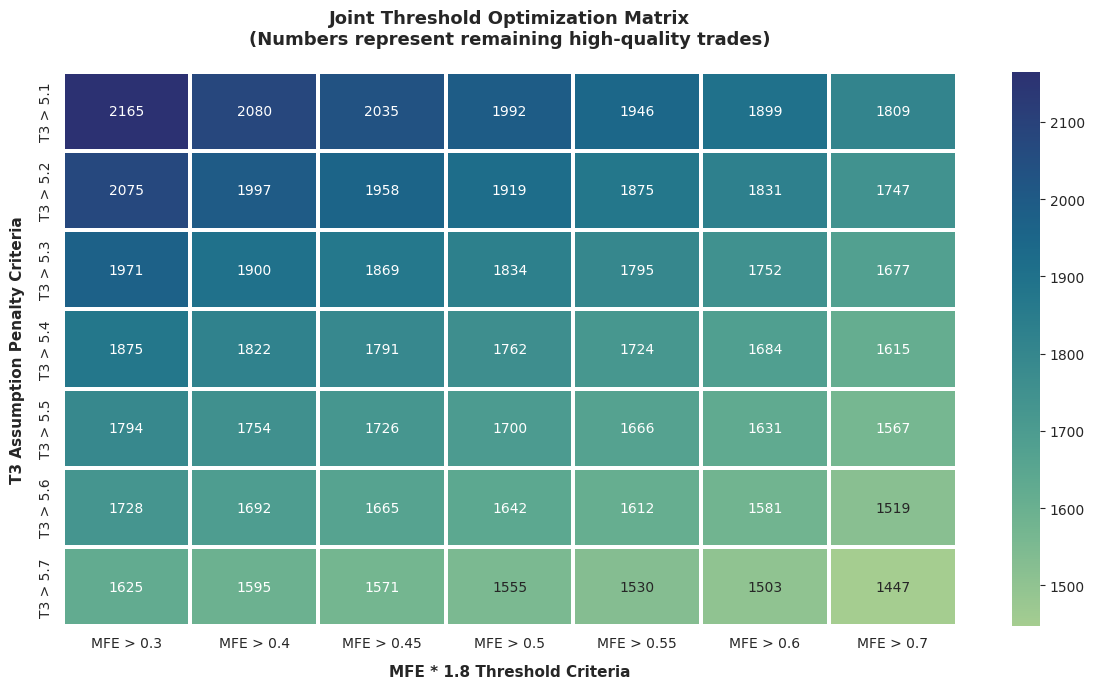

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # or import seaborn as sns

# 1. Define your exact metric milestones
mfe_points = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]
t3_variants = [5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7]

# 2. Build the matrix data
matrix_data = np.zeros((len(t3_variants), len(mfe_points)), dtype=int)

for i, t3_th in enumerate(t3_variants):
    for j, mfe_th in enumerate(mfe_points):
        # Calculate exactly how many trades survive BOTH filters
        count = len(df[
            ((df['mfe_percent'] ) > mfe_th) &
            (df['T3_Assumption_Penalty'] > t3_th)
        ])
        matrix_data[i, j] = count

# 3. Convert to a structured DataFrame for seaborn labeling
heatmap_df = pd.DataFrame(
    matrix_data,
    index=[f'T3 > {t}' for t in t3_variants],
    columns=[f'MFE > {m}' for m in mfe_points]
)

# 4. Plot the Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_df,
    annot=True,        # Places the exact trade count inside the boxes
    fmt='d',           # Ensures numbers print cleanly as integers
    cmap='crest',      # Professional gradient scaling from light to dark
    linewidths=1.5,    # Visually separates the grid blocks
    linecolor='white'
)

# 5. Formatting adjustments
plt.title('Joint Threshold Optimization Matrix\n(Numbers represent remaining high-quality trades)',
          pad=20, fontsize=13, fontweight='bold')
plt.xlabel('MFE * 1.8 Threshold Criteria', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('T3 Assumption Penalty Criteria', fontsize=11, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()

In [ ]:

# 1. Calculate metrics cleanly
Mae = df['mae_percent'].abs()
Mfe = df['mfe_percent'].abs()

# 2. Track the physical difference to catch scratches
net_excursion = Mfe - Mae

# 3. Handle math safely via np.where
# If net excursion is negative or near 0, assign a baseline efficiency of 0.1
# Otherwise, safely calculate the non-linear efficiency scale
df['target_b'] = np.where(
    net_excursion <= 1e-4,
    0.1 * Mfe,
    (Mfe / np.sqrt(np.maximum(1e-9, Mfe**2 - Mae**2))) * Mfe
)
threshold_target = 1.21
df['classification_target_2'] = (df['target_b']> threshold_target).astype(int)
display(df.groupby('signal_x')['classification_target_2'].value_counts(normalize = True)*100)
print(f'Definition A: target_special >= {threshold_target}')

display(df['classification_target_2'].value_counts(normalize = False))

signal_x  classification_target_2
LONG      0                          70.222092
          1                          29.777908
SHORT     0                          65.166569
          1                          34.833431
Name: proportion, dtype: float64

Definition A: target_special >= 1.21


,count
classification_target_2,
0,4633
1,2211


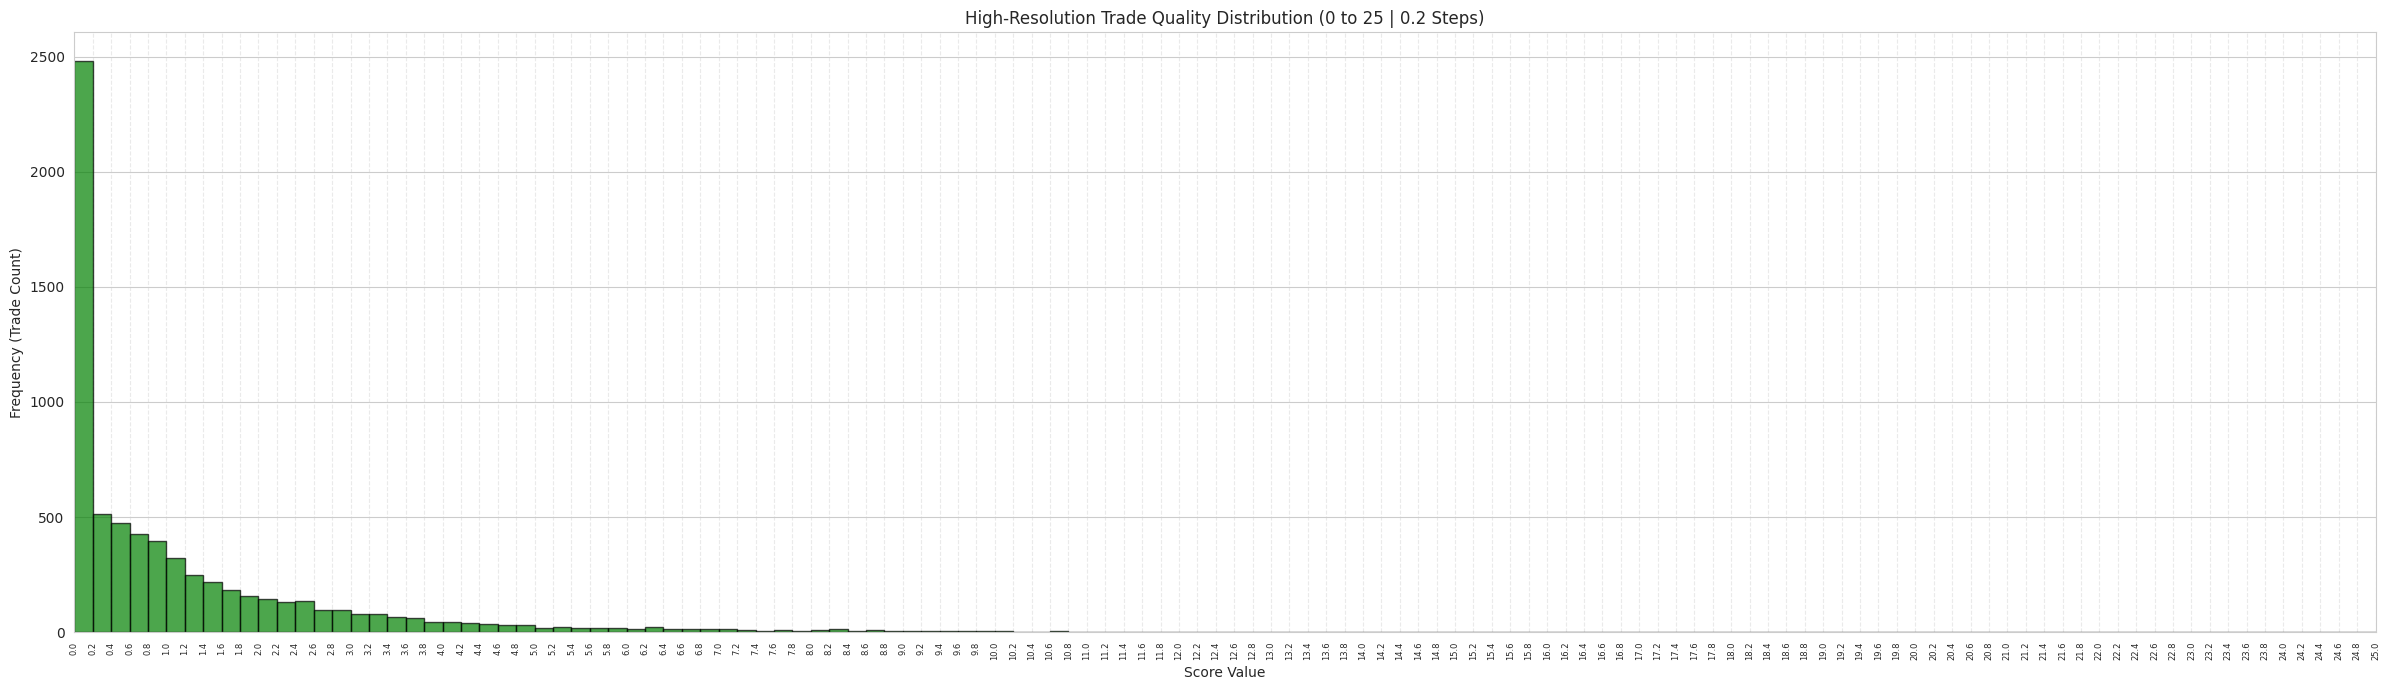

In [ ]:


# 1. Expand width so the high-resolution ticks fit cleanly
plt.figure(figsize=(24, 7))

# 2. Filter data up to 25 based on your 99.9th percentile (21.66) to capture almost everything
#    while cutting out the rare max outlier (61.55) that would squash the chart.
plot_data = df['target_b'][(df['target_b'] >= 0) & (df['target_b'] <= 25)]

# 3. Match your bin width exactly to your tick intervals (0.2 steps)
#    We go up to 25.2 to ensure the final bin captures the edge values safely
bins_alignment = np.arange(0, 25.2, 0.2)
plt.hist(plot_data, bins=bins_alignment, alpha=0.7, color='g', edgecolor='black')

# 4. Set the physical display limits of the X-axis right to 25
plt.xlim(0, 25)

# 5. Generate matching tick positions from 0 to 25 stepping by 0.2
tick_positions = np.arange(0, 25.1, 0.2)

# 6. Apply ticks with clean 90-degree rotation and a tiny font size for high-density readability
plt.xticks(tick_positions, rotation=90, fontsize=6)

plt.title('High-Resolution Trade Quality Distribution (0 to 25 | 0.2 Steps)')
plt.xlabel('Score Value')
plt.ylabel('Frequency (Trade Count)')

# Vertical grid lines help you look at a specific score bar and trace it down to its decimal value
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:


# 1. Define the range to sweep based on your descriptive stats
# Since 95% of your data is under 4.76, sweeping up to 10.0 catches everything meaningful
threshold_range = np.arange(0.0, 15.0, 0.01)

agreements = []
highest_agreement = 0
best_threshold = 0

# 2. Sweep thresholds to find where they match the most
for threshold in threshold_range:
    # Temporarily generate target 2 for this specific threshold
    temp_target_2 = (df['target_b'] > threshold).astype(int)

    # Calculate total rows where both columns are identical (1 == 1 OR 0 == 0)
    matching_rows = (df['classification_target_1'] == temp_target_2).sum()

    agreements.append(matching_rows)

    # Track the peak agreement row count
    if matching_rows > highest_agreement:
        highest_agreement = matching_rows
        best_threshold = threshold

# 3. Print out your optimization findings
total_trades = len(df)
peak_percentage = (highest_agreement / total_trades) * 100
print(f"🎯 Optimization Complete!")
print(f"Maximum Agreement Found: {highest_agreement} out of {total_trades} trades ({peak_percentage:.2f}%)")
print(f"Absolute Best Threshold for Target B: {best_threshold:.2f}")
print("-" * 50)

# 4. Lock in the optimized target into your DataFrame
df['classification_target_2'] = (df['target_b'] > best_threshold).astype(int)

# 5. Display your structural breakdown at the optimized threshold
print("\n[Optimized Class Breakdown]")
display(df['classification_target_2'].value_counts())

print("\n[Optimized Directional Distribution (%) ]")
display(df.groupby('signal_x')['classification_target_2'].value_counts(normalize=True) * 100)

🎯 Optimization Complete!
Maximum Agreement Found: 5465 out of 6844 trades (79.85%)
Absolute Best Threshold for Target B: 1.21
--------------------------------------------------

[Optimized Class Breakdown]


,count
classification_target_2,
0,4633
1,2211



[Optimized Directional Distribution (%) ]


signal_x  classification_target_2
LONG      0                          70.222092
          1                          29.777908
SHORT     0                          65.166569
          1                          34.833431
Name: proportion, dtype: float64

In [ ]:
df.loc[(df['classification_target_1'] == 0) & (df['classification_target_2'] == 1), ['mae_percent', 'mfe_percent','T3_Assumption_Penalty' ,'target_b','classification_target_1', 'classification_target_2']]

,mae_percent,mfe_percent,T3_Assumption_Penalty,target_b,classification_target_1,classification_target_2
7,-0.91,1.12,2.63,1.921226,0,1
8,-0.61,1.18,2.66,1.378479,0,1
26,-0.70,3.59,3.03,3.660255,0,1
31,-0.23,2.62,5.01,2.630154,0,1
38,-0.64,0.68,2.57,2.012338,0,1
...,...,...,...,...,...,...
6834,-0.47,2.67,5.21,2.712354,0,1
6836,-0.78,1.79,5.21,1.988744,0,1
6837,-0.99,1.60,4.03,2.036691,0,1
6841,-0.37,1.85,4.24,1.888148,0,1


In [ ]:


# ============================================================
# COMPUTE INTERSECTION TARGET (TARGET 3)
# ============================================================
# Only labels a trade as 1 if BOTH target 1 (Macro/Structure) and target 2 (Variance) agree
df['classification_target_3'] = ((df['classification_target_1'] == 1) & (df['classification_target_2'] == 1)).astype(int)

# ============================================================
# CLASS BALANCE COMPARISON TABLE GENERATION
# ============================================================

def get_target_metrics(target_col):
    pos_count = int((df[target_col] == 1).sum())
    neg_count = int((df[target_col] == 0).sum())
    pct_pos = (pos_count / len(df)) * 100

    # Handle directional queries cleanly
    longs = df[df['signal_x'].str.upper() == 'LONG'] if 'signal_x' in df.columns else pd.DataFrame()
    shorts = df[df['signal_x'].str.upper() == 'SHORT'] if 'signal_x' in df.columns else pd.DataFrame()

    long_pct = (longs[target_col] == 1).mean() * 100 if len(longs) > 0 else 0.0
    short_pct = (shorts[target_col] == 1).mean() * 100 if len(shorts) > 0 else 0.0

    return pos_count, neg_count, pct_pos, long_pct, short_pct

# Pull counts and percentages for all three final operational targets
a_pos, a_neg, a_pct, a_long, a_short = get_target_metrics('classification_target_1')
b_pos, b_neg, b_pct, b_long, b_short = get_target_metrics('classification_target_2')
c_pos, c_neg, c_pct, c_long, c_short = get_target_metrics('classification_target_3')

# Construct summary table mapping your specific codebase definitions
balance_summary = pd.DataFrame({
    'Definition':    ['A: T3_Penalty > 5.3 & MFE > 0.5', 'B: target_b > 1.21 (Variance)', 'C: Target_3 (Intersection Ensemble)'],
    'N_positive':    [a_pos, b_pos, c_pos],
    'N_negative':    [a_neg, b_neg, c_neg],
    'Pct_positive':  [f"{a_pct:.2f}%", f"{b_pct:.2f}%", f"{c_pct:.2f}%"],
    'LONG_pct_pos':  [f"{a_long:.2f}%", f"{b_long:.2f}%", f"{c_long:.2f}%"],
    'SHORT_pct_pos': [f"{a_short:.2f}%", f"{b_short:.2f}%", f"{c_short:.2f}%"],
})

print("============================================================")
print("CLASS BALANCE COMPARISON TABLE")
print("============================================================")
print(balance_summary.to_string(index=False))
print("============================================================\n")


# ====================================================================================
# ARCHITECTURAL DECISION & DUAL-TARGET TRAINING COMMENTARY
# ====================================================================================


CLASS BALANCE COMPARISON TABLE
                         Definition  N_positive  N_negative Pct_positive LONG_pct_pos SHORT_pct_pos
    A: T3_Penalty > 5.3 & MFE > 0.5        1834        5010       26.80%       21.07%        32.52%
      B: target_b > 1.21 (Variance)        2211        4633       32.31%       29.78%        34.83%
C: Target_3 (Intersection Ensemble)        1333        5511       19.48%       15.17%        23.79%



i decided to shift and reengineer my target variables


"""
STRATEGIC DIRECTION: Dual-Target Machine Learning Pipeline (Training Both A and B)

WHY WE ARE TRAINING BOTH:
Instead of forcing a synthetic compromise between two structurally distinct philosophies,
we are modeling them independently because they represent two different alpha horizons.

1. Model A (The Structure/Bias Guard):
   - Focus: Evaluates systemic alignment (BTC trend, 1D/4H market structure, context).
   - Core Mission: High False Positive (FP) mitigation. It protects capital by filtering out
     regimes where macro conditions are hostile to the signal direction, even if individual
     pips look clean.

2. Model B (The Execution Efficiency Engine):
   - Focus: Pure price action mechanics and non-linear mathematical variance ($MFE^2$ vs $MAE^2$).
   - Core Mission: Momentum and velocity classification. It favors explosive, clean
     escapes from entry over slow, grinding 'hold and hope' trades.

LIVE TRADING DEPLOYMENT MATRIX (FP COST VS FN COST):
In live production, a False Positive costs real financial capital (drawdown + slip + fees),
while a False Negative is merely an unexecuted opportunity cost ($0).

By training two separate models, we unlock the ultimate institutional execution architecture:
- High-Conviction Conservative Mode (Target 3): We filter inputs through BOTH models.
  A trade is only taken live if Model A approves the macro environment AND Model B approves
  the structural efficiency. This drives False Positives down as close to zero as possible.
- Agility Mode: We can route separate capital lines to each model to trade different
  sub-strategies (e.g., Model A handles swing positions; Model B handles high-velocity scalps).
"""


In [ ]:
# ============================================================
# LOCK IN YOUR TARGET + COMPUTE BAYES PRIOR
# ============================================================
# TODO: Set df['target'] = df['target_X']  (replace X with your chosen definition)

TARGET_BINARY_list = ['classification_target_1','classification_target_2','classification_target_3']
for targets in TARGET_BINARY_list :
    prior_pos = df[targets].mean()
    print(f'for {targets} \n\n')
    print(f'Prior P(good signal) = {prior_pos:.3f}  ({prior_pos*100:.1f}%)')
    print(f'Prior P(bad signal)  = {1-prior_pos:.3f}  ({(1-prior_pos)*100:.1f}%)')
    print()
    print(f'Dumb baseline accuracy (always predict majority): {max(prior_pos, 1-prior_pos):.3f}')
    print('Your model must beat this to be worth anything.')

    # TODO: Conditional probability exercise
    # Calculate P(good signal | ADX > 25)  vs  P(good signal | ADX <= 25)
    # Does high ADX make a good signal more or less likely on your data?
    p_good_adx_high = df[df['adx_ltf'] > 25][targets].mean()
    p_good_adx_low  = df[df['adx_ltf'] <= 25][targets].mean()
    print(f'P(good | ADX > 25):  {prior_pos:.3f}  ({prior_pos*100:.1f}%)')
    print(f'P(good | ADX <= 25): {prior_pos:.3f}  ({prior_pos*100:.1f}%)')


for classification_target_1 


Prior P(good signal) = 0.268  (26.8%)
Prior P(bad signal)  = 0.732  (73.2%)

Dumb baseline accuracy (always predict majority): 0.732
Your model must beat this to be worth anything.
P(good | ADX > 25):  0.268  (26.8%)
P(good | ADX <= 25): 0.268  (26.8%)
for classification_target_2 


Prior P(good signal) = 0.323  (32.3%)
Prior P(bad signal)  = 0.677  (67.7%)

Dumb baseline accuracy (always predict majority): 0.677
Your model must beat this to be worth anything.
P(good | ADX > 25):  0.323  (32.3%)
P(good | ADX <= 25): 0.323  (32.3%)
for classification_target_3 


Prior P(good signal) = 0.195  (19.5%)
Prior P(bad signal)  = 0.805  (80.5%)

Dumb baseline accuracy (always predict majority): 0.805
Your model must beat this to be worth anything.
P(good | ADX > 25):  0.195  (19.5%)
P(good | ADX <= 25): 0.195  (19.5%)


## Section 6 — Logistic Regression Mathematics (Tuesday)

Before writing any model code, understand what is happening under the hood.

### The core pipeline
1. Compute linear combination: `z = w₀ + w₁x₁ + ... + wₙxₙ`
2. Apply sigmoid: `σ(z) = 1 / (1 + e⁻ᶣ)` → probability between 0 and 1
3. Decision: if `σ(z) >= threshold` → predict 1 (good signal), else 0

### Log-loss
Loss = `−[y log(p) + (1−y) log(1−p)]`

### Regularisation
| | L1 (Lasso) | L2 (Ridge) |
|--|--|--|
| Penalty | λΣ|wᵢ| | λΣwᵢ² |
| Effect | Pushes weights to **exactly zero** | Shrinks all weights |
| Use when | Many features are irrelevant | All features contribute |
| sklearn | `penalty='l1'`, `solver='liblinear'` | `penalty='l2'` (default) |

`C = 1/λ` — **higher C = less regularisation = more complex model**

> **Deliverable for Tuesday:** 2 pages of handwritten derivations. Work through the gradient of log-loss with respect to one weight, then the L2 penalty term. Do this before running any code.


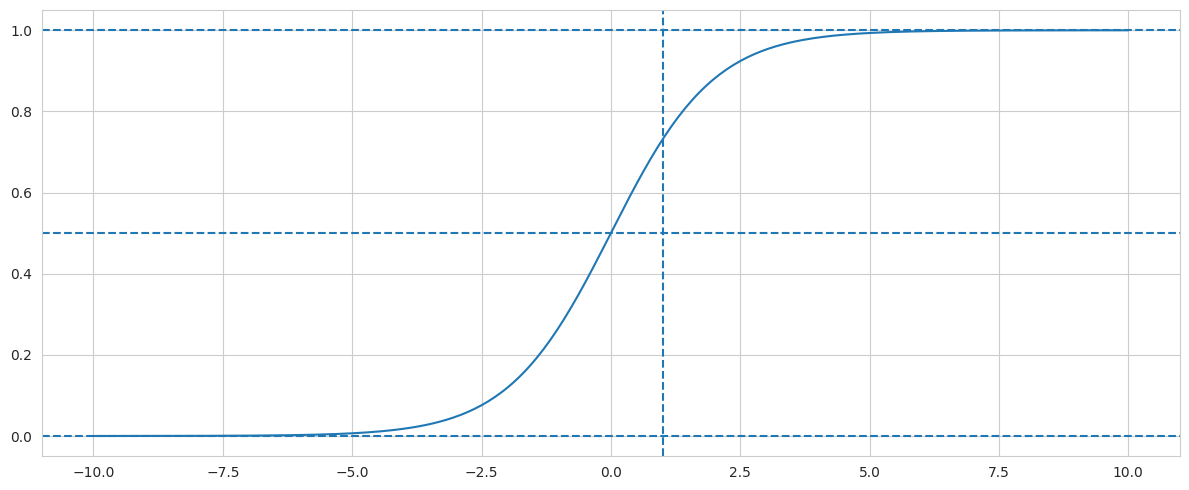

In [ ]:
# ============================================================
# SIGMOID FUNCTION
# ============================================================
z = np.linspace(-10, 10, 300)

# TODO: sigma = 1 / (1 + np.exp(-z))
sigma = 1 /  (1 + np.exp(-z))


# TODO: ax.plot(z, sigma)
plt.plot( z, sigma)
# Add dashed horizontals at y=0, 0.5, 1
plt.axhline( y = 0 , linestyle = '--')
plt.axhline( y = 0.5 , linestyle = '--')
plt.axhline( y = 1 , linestyle = '--')
# Add dashed vertical at x=0
plt.axvline( x = 1, linestyle = '--')
# Annotate the decision boundary point (0, 0.5)
# Title: 'Sigmoid Function - Logistic Regression Output'
plt.tight_layout()
plt.show()

# TODO: Answer in comments:
# 1. sigma(0) = ?
# 2. sigma(10) ~= ?
# 3. sigma(-10) ~= ?
# 4. At what z does the model flip its prediction (default threshold)?


In [ ]:
# ============================================================
# LOG-LOSS: manual implementation + verification
# ============================================================

def log_loss_manual(y_true, y_prob):
    """
    Binary cross-entropy: -mean[y*log(p) + (1-y)*log(1-p)]
    Clip p to avoid log(0).
    """
    # TODO: clip p to (1e-9, 1-1e-9)
    p = y_prob
    y = y_true
    p = np.clip(p, 1e-9, 1-1e-9)
    # TODO: compute element-wise loss, return mean
    log_loss_manual = -np.mean(y*(np.log(p)) + (1-y)*(np.log(1-p)))
    return log_loss_manual
    pass

y_sample = np.array([1, 0, 1, 1, 0, 0, 1])
p_sample  = np.array([0.9, 0.2, 0.7, 0.5, 0.8, 0.5, 0.4])

manual = log_loss_manual(y_sample, p_sample)
print(f'Manual log-loss:  {manual}')

# Verify against sklearn:
from sklearn.metrics import log_loss
print(f'sklearn log-loss: {log_loss(y_sample, p_sample)}')

# Hand calculation for one sample (y=1, p=0.7):
print(f'Single sample (y=1, p=0.7): loss = {-np.log(0.7):.4f}')
# TODO: In a comment: what happens to the loss as p -> 0 for a true positive?


Manual log-loss:  0.6567431451912735
sklearn log-loss: 0.6567431451912735
Single sample (y=1, p=0.7): loss = 0.3567


## Section 7 — Baseline Logistic Regression — LONG Signals (Wednesday)

Train `LogisticRegression(C=1.0)` on your binary target. Time-based 80/20 split, scale on train only.

> **Trading interpretation of the confusion matrix:**
> - **FP** (model says good, trade is bad) → bad trade entered, capital at risk
> - **FN** (model says bad, trade is good) → missed winner, opportunity cost
> - **TP** → correctly identified good entry
> - **TN** → correctly avoided a loser

> For a live system with limited capital, FP is usually more costly than FN. Your threshold tuning in Section 9 should reflect your personal answer to this.


In [ ]:
TARGET_BINARY_list = ['classification_target_1','classification_target_2','classification_target_3']
TARGET_BINARY = TARGET_BINARY_list[0]

In [ ]:
# ============================================================
# LONG SIGNALS: data prep
# ============================================================
FEATURES = FEATURES_LONG_MI

df_long = df[df['signal_x'] == 'LONG'].copy()
df_long = df_long[['checked_at_utc', 'symbol'] + FEATURES + [TARGET_BINARY]].dropna()

print(f'LONG signals: {len(df_long):,} rows')
print(f'Class balance: {df_long[TARGET_BINARY].mean()*100:.1f}% positive')
print(f'NaN remaining: {df_long.isna().sum().sum()}')


LONG signals: 3,422 rows
Class balance: 21.1% positive
NaN remaining: 0


In [ ]:
# ============================================================
# TIME-BASED TRAIN/TEST SPLIT: 80/20 chronological
# ============================================================

long_sorted = df_long.sort_values('checked_at_utc').reset_index(drop=True)
split_idx   = int(len(long_sorted) * 0.8)

train_long = long_sorted.iloc[:split_idx]
test_long  = long_sorted.iloc[split_idx:]

assert train_long['checked_at_utc'].max() <= test_long['checked_at_utc'].min(), 'Time leakage!'

print(f'Train: {len(train_long):,} rows | {train_long["checked_at_utc"].min().date()} to {train_long["checked_at_utc"].max().date()}')
print(f'Test:  {len(test_long):,} rows  | {test_long["checked_at_utc"].min().date()} to {test_long["checked_at_utc"].max().date()}')
print(f'Train balance: {train_long[TARGET_BINARY].mean()*100:.1f}% positive')
print(f'Test  balance: {test_long[TARGET_BINARY].mean()*100:.1f}% positive')


Train: 2,737 rows | 2025-10-03 to 2026-04-26
Test:  685 rows  | 2026-04-26 to 2026-06-17
Train balance: 20.2% positive
Test  balance: 24.7% positive


In [ ]:
# ============================================================
# SCALING: fit on train, transform both
# ============================================================
scaler_long = StandardScaler()

X_train_long = train_long[FEATURES].values
y_train_long = train_long[TARGET_BINARY].values
X_test_long  = test_long[FEATURES].values
y_test_long  = test_long[TARGET_BINARY].values

X_train_long_sc = scaler_long.fit_transform(X_train_long)
X_test_long_sc  = scaler_long.transform(X_test_long)

print('Scaling check (first 5 features):')
print(f'  Train mean (~0): {X_train_long_sc.mean(axis=0)[:24].round(3)}')
print(f'  Train std  (~1): {X_train_long_sc.std(axis=0)[:24].round(3)}')
print(f'  Test  mean (!=0): {X_test_long_sc.mean(axis=0)[:24].round(3)}')
# TODO: In a comment - why is the test mean not exactly 0?


Scaling check (first 5 features):
  Train mean (~0): [ 0.  0. -0.  0.  0. -0. -0.  0. -0.  0. -0.  0.  0. -0. -0.]
  Train std  (~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Test  mean (!=0): [-0.033 -0.008 -0.056  0.067  0.036 -0.148 -0.148  0.281 -0.326 -0.183
 -0.017  0.113 -0.145 -0.065  0.076]


In [ ]:


# ============================================================
# TRAIN BASELINE LOGISTIC REGRESSION
# ============================================================
# Initialise with default class weights (unbalanced)
lr_long = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', class_weight= 'balanced')

# Fit on X_train_long_sc, y_train_long
lr_long.fit(X_train_long_sc, y_train_long)

# Get the default predictions (using the 0.5 threshold)
y_pred_long = lr_long.predict(X_test_long_sc)

# Get the raw probabilities for the positive class (1)
y_prob_long = lr_long.predict_proba(X_test_long_sc)[:, 1]


# Compute baseline metrics
acc  = accuracy_score(y_test_long, y_pred_long)
prec = precision_score(y_test_long, y_pred_long, zero_division=0)
rec  = recall_score(y_test_long, y_pred_long)
f1   = f1_score(y_test_long, y_pred_long)
auc  = roc_auc_score(y_test_long, y_prob_long)

print('=' * 50)
print(f' LOGISTIC REGRESSION BASELINE {TARGET_BINARY} - LONG signals')
print('=' * 50)
print(f'  Accuracy:  {acc}')
print(f'  Precision: {prec}  <- of signals flagged good, how many were?')
print(f'  Recall:    {rec}   <- of all good signals, how many caught?')
print(f'  F1-Score:  {f1}')
print(f'  ROC-AUC:   {auc}')
print()
dumb = max(y_test_long.mean(), 1-y_test_long.mean())
print(f'  Dumb baseline accuracy: {dumb:.4f}')
print(f'  Beating it? {"YES" if acc and acc > dumb else "NO"}')
print()

# ============================================================
# THRESHOLD SWEEP (FINDING THE ALPHA SWEET SPOT)
# ============================================================
print('=' * 50)
print(' OVERSHOT MONITOR: TESTING CUSTOM THRESHOLDS (Unbalanced Model)')
print('=' * 50)

# Since your probabilities are squashed below 0.5, we test lower cutoffs
for thresh in [ 0.61, 0.62, 0.63, 0.64, 0.65, 0.66]:
    # Form hard binary predictions using the custom threshold slice
    custom_preds = (y_prob_long >= thresh).astype(int)

    # Compute the matrix components manually for full transparency
    tn, fp, fn, tp = confusion_matrix(y_test_long, custom_preds).ravel()

    t_prec = precision_score(y_test_long, custom_preds, zero_division=0)
    t_rec  = recall_score(y_test_long, custom_preds)
    t_f1   = f1_score(y_test_long, custom_preds)

    print(f"Thresh: {thresh:.2f} | Prec: {t_prec:.4f} | Rec: {t_rec:.4f} | F1: {t_f1:.4f} | [TN : {tn}, TP: {tp}, FP: {fp}, FN: {fn}]")
print('=' * 50)

 LOGISTIC REGRESSION BASELINE classification_target_1 - LONG signals
  Accuracy:  0.7153284671532847
  Precision: 0.44881889763779526  <- of signals flagged good, how many were?
  Recall:    0.6745562130177515   <- of all good signals, how many caught?
  F1-Score:  0.5390070921985816
  ROC-AUC:   0.7655497454245219

  Dumb baseline accuracy: 0.7533
  Beating it? NO

 OVERSHOT MONITOR: TESTING CUSTOM THRESHOLDS (Unbalanced Model)
Thresh: 0.61 | Prec: 0.4852 | Rec: 0.4852 | F1: 0.4852 | [TN : 429, TP: 82, FP: 87, FN: 87]
Thresh: 0.62 | Prec: 0.4873 | Rec: 0.4556 | F1: 0.4709 | [TN : 435, TP: 77, FP: 81, FN: 92]
Thresh: 0.63 | Prec: 0.4966 | Rec: 0.4320 | F1: 0.4620 | [TN : 442, TP: 73, FP: 74, FN: 96]
Thresh: 0.64 | Prec: 0.5182 | Rec: 0.4201 | F1: 0.4641 | [TN : 450, TP: 71, FP: 66, FN: 98]
Thresh: 0.65 | Prec: 0.5385 | Rec: 0.4142 | F1: 0.4682 | [TN : 456, TP: 70, FP: 60, FN: 99]
Thresh: 0.66 | Prec: 0.5360 | Rec: 0.3964 | F1: 0.4558 | [TN : 458, TP: 67, FP: 58, FN: 102]


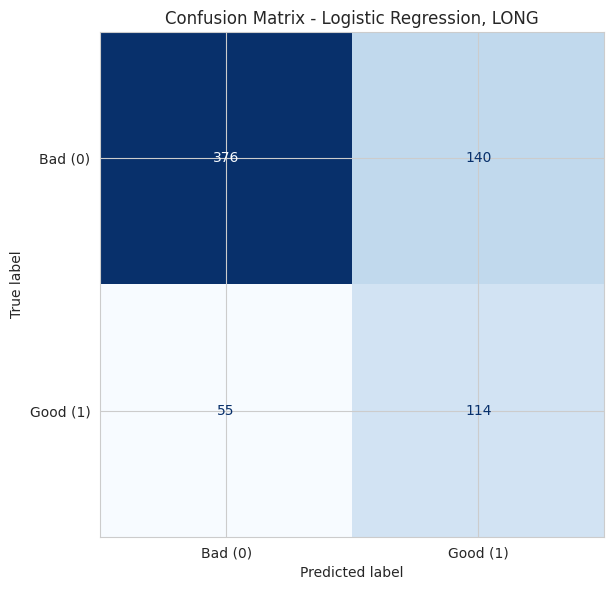

TN = 376  correctly avoided bad trades
FP = 140  bad trades entered wrongly  <- COSTLY
FN = 55  good trades missed           <- opportunity cost
TP = 114  good trades correctly caught

FP Rate: 27.1%
FN Rate: 32.5%


In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================
cm   = confusion_matrix(y_test_long, y_pred_long)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad (0)', 'Good (1)'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Logistic Regression, LONG')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN = {tn:,}  correctly avoided bad trades')
print(f'FP = {fp:,}  bad trades entered wrongly  <- COSTLY')
print(f'FN = {fn:,}  good trades missed           <- opportunity cost')
print(f'TP = {tp:,}  good trades correctly caught')
print()
print(f'FP Rate: {fp/(fp+tn)*100:.1f}%')
print(f'FN Rate: {fn/(fn+tp)*100:.1f}%')
# TODO: Comment - which error is more costly for your strategy?


LONG signals: 3,422 rows
Class balance: 21.1% positive
NaN remaining: 0
Train: 2,737 rows | 2025-10-03 to 2026-04-26
Test:  685 rows  | 2026-04-26 to 2026-06-17
Train balance: 20.2% positive
Test  balance: 24.7% positive
Scaling check (first 5 features):
  Train mean (~0): [ 0.  0. -0.  0.  0. -0. -0.  0. -0.  0. -0.  0.  0. -0. -0.]
  Train std  (~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Test  mean (!=0): [-0.033 -0.008 -0.056  0.067  0.036 -0.148 -0.148  0.281 -0.326 -0.183
 -0.017  0.113 -0.145 -0.065  0.076]
 LOGISTIC REGRESSION BASELINE classification_target_1 - LONG signals
  Accuracy:  0.7153284671532847
  Precision: 0.44881889763779526  <- of signals flagged good, how many were?
  Recall:    0.6745562130177515   <- of all good signals, how many caught?
  F1-Score:  0.5390070921985816
  ROC-AUC:   0.7655497454245219

  Dumb baseline accuracy: 0.7533
  Beating it? NO

 OVERSHOT MONITOR: TESTING CUSTOM THRESHOLDS (Unbalanced Model)
Thresh: 0.61 | Prec: 0.4852 | Rec: 0.

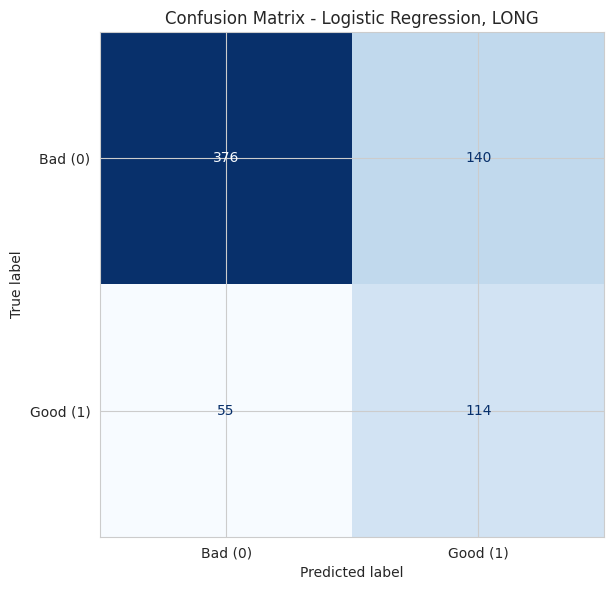

TN = 376  correctly avoided bad trades
FP = 140  bad trades entered wrongly  <- COSTLY
FN = 55  good trades missed           <- opportunity cost
TP = 114  good trades correctly caught

FP Rate: 27.1%
FN Rate: 32.5%
LONG signals: 3,422 rows
Class balance: 29.8% positive
NaN remaining: 0
Train: 2,737 rows | 2025-10-03 to 2026-04-26
Test:  685 rows  | 2026-04-26 to 2026-06-17
Train balance: 31.2% positive
Test  balance: 23.9% positive
Scaling check (first 5 features):
  Train mean (~0): [ 0.  0. -0.  0.  0. -0. -0.  0. -0.  0. -0.  0.  0. -0. -0.]
  Train std  (~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Test  mean (!=0): [-0.033 -0.008 -0.056  0.067  0.036 -0.148 -0.148  0.281 -0.326 -0.183
 -0.017  0.113 -0.145 -0.065  0.076]
 LOGISTIC REGRESSION BASELINE classification_target_2 - LONG signals
  Accuracy:  0.7386861313868613
  Precision: 0.4623115577889447  <- of signals flagged good, how many were?
  Recall:    0.5609756097560976   <- of all good signals, how many caught?
  F

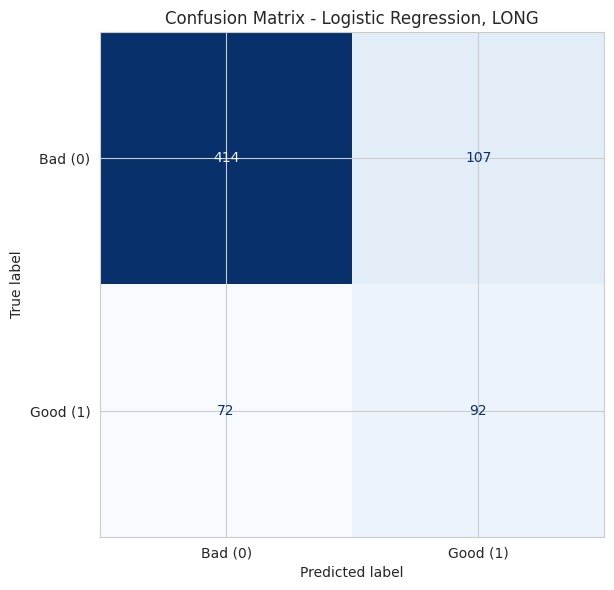

TN = 414  correctly avoided bad trades
FP = 107  bad trades entered wrongly  <- COSTLY
FN = 72  good trades missed           <- opportunity cost
TP = 92  good trades correctly caught

FP Rate: 20.5%
FN Rate: 43.9%
LONG signals: 3,422 rows
Class balance: 15.2% positive
NaN remaining: 0
Train: 2,737 rows | 2025-10-03 to 2026-04-26
Test:  685 rows  | 2026-04-26 to 2026-06-17
Train balance: 15.5% positive
Test  balance: 13.9% positive
Scaling check (first 5 features):
  Train mean (~0): [ 0.  0. -0.  0.  0. -0. -0.  0. -0.  0. -0.  0.  0. -0. -0.]
  Train std  (~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Test  mean (!=0): [-0.033 -0.008 -0.056  0.067  0.036 -0.148 -0.148  0.281 -0.326 -0.183
 -0.017  0.113 -0.145 -0.065  0.076]
 LOGISTIC REGRESSION BASELINE classification_target_3 - LONG signals
  Accuracy:  0.724087591240876
  Precision: 0.2882882882882883  <- of signals flagged good, how many were?
  Recall:    0.6736842105263158   <- of all good signals, how many caught?
  F1-

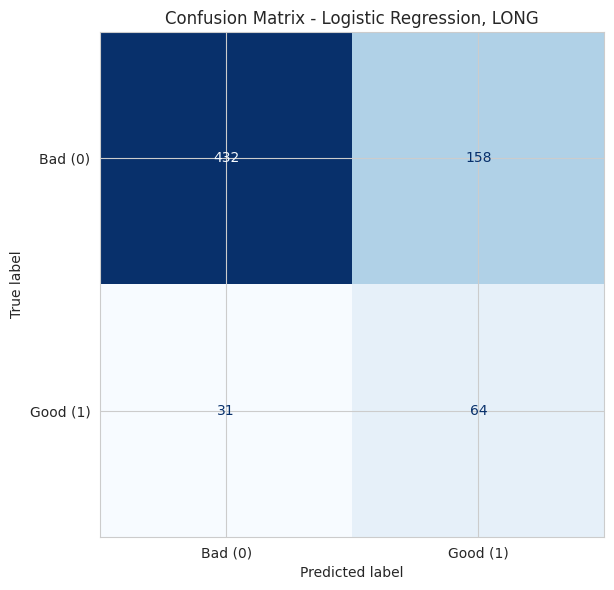

TN = 432  correctly avoided bad trades
FP = 158  bad trades entered wrongly  <- COSTLY
FN = 31  good trades missed           <- opportunity cost
TP = 64  good trades correctly caught

FP Rate: 26.8%
FN Rate: 32.6%


In [ ]:


# ============================================================
# LONG SIGNALS: data prep
# ============================================================
FEATURES = FEATURES_LONG_MI
TARGET_BINARY_list = ['classification_target_1','classification_target_2','classification_target_3']
for TARGET_BINARY in TARGET_BINARY_list:
    df_long = df[df['signal_x'] == 'LONG'].copy()
    df_long = df_long[['checked_at_utc', 'symbol'] + FEATURES + [TARGET_BINARY]].dropna()

    print(f'LONG signals: {len(df_long):,} rows')
    print(f'Class balance: {df_long[TARGET_BINARY].mean()*100:.1f}% positive')
    print(f'NaN remaining: {df_long.isna().sum().sum()}')
    # ============================================================
    # TIME-BASED TRAIN/TEST SPLIT: 80/20 chronological
    # ============================================================

    long_sorted = df_long.sort_values('checked_at_utc').reset_index(drop=True)
    split_idx   = int(len(long_sorted) * 0.8)

    train_long = long_sorted.iloc[:split_idx]
    test_long  = long_sorted.iloc[split_idx:]

    assert train_long['checked_at_utc'].max() <= test_long['checked_at_utc'].min(), 'Time leakage!'

    print(f'Train: {len(train_long):,} rows | {train_long["checked_at_utc"].min().date()} to {train_long["checked_at_utc"].max().date()}')
    print(f'Test:  {len(test_long):,} rows  | {test_long["checked_at_utc"].min().date()} to {test_long["checked_at_utc"].max().date()}')
    print(f'Train balance: {train_long[TARGET_BINARY].mean()*100:.1f}% positive')
    print(f'Test  balance: {test_long[TARGET_BINARY].mean()*100:.1f}% positive')
    # ============================================================
    # SCALING: fit on train, transform both
    # ============================================================
    scaler_long = StandardScaler()

    X_train_long = train_long[FEATURES].values
    y_train_long = train_long[TARGET_BINARY].values
    X_test_long  = test_long[FEATURES].values
    y_test_long  = test_long[TARGET_BINARY].values

    X_train_long_sc = scaler_long.fit_transform(X_train_long)
    X_test_long_sc  = scaler_long.transform(X_test_long)

    print('Scaling check (first 5 features):')
    print(f'  Train mean (~0): {X_train_long_sc.mean(axis=0)[:24].round(3)}')
    print(f'  Train std  (~1): {X_train_long_sc.std(axis=0)[:24].round(3)}')
    print(f'  Test  mean (!=0): {X_test_long_sc.mean(axis=0)[:24].round(3)}')
    # TODO: In a comment - why is the test mean not exactly 0?
    # ============================================================
    # TRAIN BASELINE LOGISTIC REGRESSION
    # ============================================================
    # Initialise with default class weights (unbalanced)
    lr_long = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', class_weight= 'balanced')

    # Fit on X_train_long_sc, y_train_long
    lr_long.fit(X_train_long_sc, y_train_long)

    # Get the default predictions (using the 0.5 threshold)
    y_pred_long = lr_long.predict(X_test_long_sc)

    # Get the raw probabilities for the positive class (1)
    y_prob_long = lr_long.predict_proba(X_test_long_sc)[:, 1]


    # Compute baseline metrics
    acc  = accuracy_score(y_test_long, y_pred_long)
    prec = precision_score(y_test_long, y_pred_long, zero_division=0)
    rec  = recall_score(y_test_long, y_pred_long)
    f1   = f1_score(y_test_long, y_pred_long)
    auc  = roc_auc_score(y_test_long, y_prob_long)

    print('=' * 50)
    print(f' LOGISTIC REGRESSION BASELINE {TARGET_BINARY} - LONG signals')
    print('=' * 50)
    print(f'  Accuracy:  {acc}')
    print(f'  Precision: {prec}  <- of signals flagged good, how many were?')
    print(f'  Recall:    {rec}   <- of all good signals, how many caught?')
    print(f'  F1-Score:  {f1}')
    print(f'  ROC-AUC:   {auc}')
    print()
    dumb = max(y_test_long.mean(), 1-y_test_long.mean())
    print(f'  Dumb baseline accuracy: {dumb:.4f}')
    print(f'  Beating it? {"YES" if acc and acc > dumb else "NO"}')
    print()

    # ============================================================
    # THRESHOLD SWEEP (FINDING THE ALPHA SWEET SPOT)
    # ============================================================
    print('=' * 50)
    print(' OVERSHOT MONITOR: TESTING CUSTOM THRESHOLDS (Unbalanced Model)')
    print('=' * 50)

    # Since your probabilities are squashed below 0.5, we test lower cutoffs
    for thresh in [ 0.61, 0.62, 0.63, 0.64, 0.65, 0.66]:
        # Form hard binary predictions using the custom threshold slice
        custom_preds = (y_prob_long >= thresh).astype(int)

        # Compute the matrix components manually for full transparency
        tn, fp, fn, tp = confusion_matrix(y_test_long, custom_preds).ravel()

        t_prec = precision_score(y_test_long, custom_preds, zero_division=0)
        t_rec  = recall_score(y_test_long, custom_preds)
        t_f1   = f1_score(y_test_long, custom_preds)

        print(f"Thresh: {thresh:.2f} | Prec: {t_prec:.4f} | Rec: {t_rec:.4f} | F1: {t_f1:.4f} | [TN : {tn}, TP: {tp}, FP: {fp}, FN: {fn}]")
    print('=' * 50)# ============================================================
    # CONFUSION MATRIX
    # ============================================================
    cm   = confusion_matrix(y_test_long, y_pred_long)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad (0)', 'Good (1)'])

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title('Confusion Matrix - Logistic Regression, LONG')
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f'TN = {tn:,}  correctly avoided bad trades')
    print(f'FP = {fp:,}  bad trades entered wrongly  <- COSTLY')
    print(f'FN = {fn:,}  good trades missed           <- opportunity cost')
    print(f'TP = {tp:,}  good trades correctly caught')
    print()
    print(f'FP Rate: {fp/(fp+tn)*100:.1f}%')
    print(f'FN Rate: {fn/(fn+tp)*100:.1f}%')
    # TODO: Comment - which error is more costly for your strategy?

In [ ]:
# ============================================================
# MASTER LOOP: COINS & TARGETS PIPELINE
# ============================================================
FEATURES = FEATURES_LONG_MI
TARGET_BINARY_list = ['classification_target_1', 'classification_target_2', 'classification_target_3']

# Extract your tracked assets dynamically (e.g., SOLUSDT, ETHUSDT, BTCUSDT, etc.)
COIN_LIST = df[df['signal_x'] == 'LONG']['symbol'].unique()

for coin in COIN_LIST:
    print("\n" + "#" * 70)
    print(f" PROFILE GENERATION FOR ASSET: {coin}")
    print("#" * 70)

    # Isolate data purely for this specific coin
    df_coin_master = df[(df['signal_x'] == 'LONG') & (df['symbol'] == coin)].copy()

    if len(df_coin_master) < 100:  # Safety check for sparse asset data
        print(f"Skipping {coin} due to insufficient row count ({len(df_coin_master)} rows).")
        continue

    for TARGET_BINARY in TARGET_BINARY_list:
        # Drop rows missing features or target for this specific run
        df_run = df_coin_master[['checked_at_utc', 'symbol'] + FEATURES + [TARGET_BINARY]].dropna()

        if len(df_run) < 50:
            continue

        # Time-Based Split (Chronological 80/20)
        run_sorted = df_run.sort_values('checked_at_utc').reset_index(drop=True)
        split_idx  = int(len(run_sorted) * 0.8)

        train_set = run_sorted.iloc[:split_idx]
        test_set  = run_sorted.iloc[split_idx:]

        X_train = train_set[FEATURES].values
        y_train = train_set[TARGET_BINARY].values
        X_test  = test_set[FEATURES].values
        y_test  = test_set[TARGET_BINARY].values

        # Scaling (Fit train, transform both)
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        # Initialize and fit model using balanced weights
        lr_model = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', class_weight='balanced', random_state=42)
        lr_model.fit(X_train_sc, y_train)

        # Baseline predictions (0.50 threshold)
        y_pred = lr_model.predict(X_test_sc)
        y_prob = lr_model.predict_proba(X_test_sc)[:, 1]

        # Baseline Metrics
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred)
        auc  = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0.5
        dumb = max(y_test.mean(), 1 - y_test.mean())

        print("\n" + "-" * 60)
        print(f" ASSET: {coin} | TARGET: {TARGET_BINARY}")
        print("-" * 60)
        print(f"  Test Samples: {len(test_set)} rows (Balance: {y_test.mean()*100:.1f}% Positive)")
        print(f"  Baseline (0.50) -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | ROC-AUC: {auc:.4f} | Dumb Acc: {dumb:.4f}")
        print(f"  Beating Dumb Baseline? {'YES' if acc > dumb else 'NO'}")
        print("\n  Custom Execution Sweep Matrix:")

        # Threshold Execution Matrix
        for thresh in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
            custom_preds = (y_prob >= thresh).astype(int)

            # Catch instances where a strict threshold results in zero trades triggered
            if not np.any(custom_preds):
                print(f"    Thresh: {thresh:.2f} | NO SIGNALS TRIGGERED")
                continue

            tn, fp, fn, tp = confusion_matrix(y_test, custom_preds, labels=[0, 1]).ravel()
            t_prec = precision_score(y_test, custom_preds, zero_division=0)
            t_rec  = recall_score(y_test, custom_preds)

            print(f"    Thresh: {thresh:.2f} | Prec: {t_prec:.4f} | Rec: {t_rec:.4f} | [TN: {tn}, TP: {tp}, FP: {fp}, FN: {fn}]")


######################################################################
 PROFILE GENERATION FOR ASSET: XRPUSDT
######################################################################

------------------------------------------------------------
 ASSET: XRPUSDT | TARGET: classification_target_1
------------------------------------------------------------
  Test Samples: 136 rows (Balance: 21.3% Positive)
  Baseline (0.50) -> Acc: 0.6397 | Prec: 0.3214 | Rec: 0.6207 | ROC-AUC: 0.7067 | Dumb Acc: 0.7868
  Beating Dumb Baseline? NO

  Custom Execution Sweep Matrix:
    Thresh: 0.55 | Prec: 0.3200 | Rec: 0.5517 | [TN: 73, TP: 16, FP: 34, FN: 13]
    Thresh: 0.60 | Prec: 0.2750 | Rec: 0.3793 | [TN: 78, TP: 11, FP: 29, FN: 18]
    Thresh: 0.65 | Prec: 0.3333 | Rec: 0.3793 | [TN: 85, TP: 11, FP: 22, FN: 18]
    Thresh: 0.70 | Prec: 0.4500 | Rec: 0.3103 | [TN: 96, TP: 9, FP: 11, FN: 20]
    Thresh: 0.75 | Prec: 0.4706 | Rec: 0.2759 | [TN: 98, TP: 8, FP: 9, FN: 21]
    Thresh: 0.80 | Prec: 0.5455

In [ ]:
# ============================================================
# MASTER LOOP: COINS & TARGETS PIPELINE
# ============================================================
import warnings
warnings.filterwarnings('ignore')

FEATURES = FEATURES_ALL
TARGET_BINARY_LIST = ['classification_target_1', 'classification_target_2', 'classification_target_3']
THRESHOLDS         = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
MIN_TP_FLOOR       = 10   # Ignore precision readings with fewer than this many true positives
MIN_COIN_ROWS      = 100  # Skip asset if total rows below this
MIN_RUN_ROWS       = 50   # Skip target if rows after dropna below this

COIN_LIST = sorted(df[df['signal_x'] == 'LONG']['symbol'].unique())

# Collector for cross-asset summary at the end
summary_rows = []

for coin in COIN_LIST:
    print("\n" + "#" * 70)
    print(f" PROFILE GENERATION FOR ASSET: {coin}")
    print("#" * 70)

    df_coin_master = df[(df['signal_x'] == 'LONG') & (df['symbol'] == coin)].copy()

    if len(df_coin_master) < MIN_COIN_ROWS:
        print(f"  ⚠ Skipping {coin} — insufficient rows ({len(df_coin_master)})")
        continue

    for TARGET_BINARY in TARGET_BINARY_LIST:
        df_run = df_coin_master[['checked_at_utc', 'symbol'] + FEATURES + [TARGET_BINARY]].dropna()

        if len(df_run) < MIN_RUN_ROWS:
            print(f"\n  ⚠ Skipping {TARGET_BINARY} for {coin} — only {len(df_run)} rows after dropna")
            continue

        # ── Time-based 80/20 split ──────────────────────────────────────
        run_sorted = df_run.sort_values('checked_at_utc').reset_index(drop=True)
        split_idx  = int(len(run_sorted) * 0.8)
        train_set  = run_sorted.iloc[:split_idx]
        test_set   = run_sorted.iloc[split_idx:]

        # Sanity check: no time leakage
        assert train_set['checked_at_utc'].max() <= test_set['checked_at_utc'].min(), \
            f"⛔ Time leakage detected for {coin} / {TARGET_BINARY}"

        X_train = train_set[FEATURES].values
        y_train = train_set[TARGET_BINARY].values
        X_test  = test_set[FEATURES].values
        y_test  = test_set[TARGET_BINARY].values

        # Guard: skip if test set has only one class (AUC undefined)
        if len(np.unique(y_test)) < 2:
            print(f"\n  ⚠ Skipping {TARGET_BINARY} for {coin} — test set has only one class")
            continue

        # ── Scaling ─────────────────────────────────────────────────────
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        # ── Model ───────────────────────────────────────────────────────
        lr_model = LogisticRegression(
            C=1.0, max_iter=1000, solver='lbfgs',
            class_weight='balanced', random_state=42
        )
        lr_model.fit(X_train_sc, y_train)

        y_pred = lr_model.predict(X_test_sc)
        y_prob = lr_model.predict_proba(X_test_sc)[:, 1]

        # ── Baseline metrics ────────────────────────────────────────────
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        auc  = roc_auc_score(y_test, y_prob)
        dumb = max(y_test.mean(), 1 - y_test.mean())
        pos_rate = y_test.mean()

        beats_dumb = acc > dumb
        auc_flag   = " 🔥" if auc >= 0.80 else (" ✓" if auc >= 0.70 else "")

        print("\n" + "-" * 60)
        print(f" ASSET: {coin} | TARGET: {TARGET_BINARY}")
        print("-" * 60)
        print(f"  Rows — Train: {len(train_set)} | Test: {len(test_set)} "
              f"(Positive rate: {pos_rate*100:.1f}%)")
        print(f"  Train window: {train_set['checked_at_utc'].min().date()} → "
              f"{train_set['checked_at_utc'].max().date()}")
        print(f"  Test  window: {test_set['checked_at_utc'].min().date()}  → "
              f"{test_set['checked_at_utc'].max().date()}")
        print(f"  Baseline (0.50) → Prec: {prec:.4f} | Rec: {rec:.4f} | "
              f"AUC: {auc:.4f}{auc_flag} | Dumb Acc: {dumb:.4f}")
        print(f"  Beats dumb baseline? {'✅ YES' if beats_dumb else '❌ NO'}")
        print(f"\n  Threshold Sweep  (✱ = TP ≥ {MIN_TP_FLOOR}, statistically meaningful)")
        print(f"  {'Thresh':>7} | {'Prec':>6} | {'Rec':>6} | {'F1':>6} | "
              f"{'TP':>4} | {'FP':>4} | {'FN':>4} | {'TN':>4} | Note")
        print(f"  {'-'*80}")

        best_thresh_row = None  # track best F1 with TP >= floor

        for thresh in THRESHOLDS:
            custom_preds = (y_prob >= thresh).astype(int)

            if not np.any(custom_preds):
                print(f"  {thresh:>7.2f} | — no signals triggered at this threshold —")
                continue

            tn, fp, fn, tp = confusion_matrix(y_test, custom_preds, labels=[0, 1]).ravel()
            t_prec = precision_score(y_test, custom_preds, zero_division=0)
            t_rec  = recall_score(y_test, custom_preds, zero_division=0)
            t_f1   = f1_score(y_test, custom_preds, zero_division=0)

            meaningful = tp >= MIN_TP_FLOOR
            marker     = " ✱" if meaningful else "  "

            # Flag high-precision rows
            highlight = ""
            if meaningful and t_prec >= 0.60:
                highlight = " ← HIGH PREC"
            elif meaningful and t_prec >= 0.50:
                highlight = " ← usable"

            print(f"  {thresh:>7.2f} | {t_prec:>6.4f} | {t_rec:>6.4f} | {t_f1:>6.4f} | "
                  f"{tp:>4} | {fp:>4} | {fn:>4} | {tn:>4} |{marker}{highlight}")

            # Track best meaningful F1
            if meaningful and (best_thresh_row is None or t_f1 > best_thresh_row['f1']):
                best_thresh_row = {
                    'coin': coin, 'target': TARGET_BINARY,
                    'thresh': thresh, 'prec': t_prec, 'rec': t_rec,
                    'f1': t_f1, 'tp': tp, 'fp': fp, 'fn': fn, 'auc': auc,
                    'pos_rate': pos_rate
                }

        # ── Per-combo verdict ───────────────────────────────────────────
        if best_thresh_row:
            print(f"\n  ★ Best meaningful threshold: {best_thresh_row['thresh']:.2f} → "
                  f"Prec {best_thresh_row['prec']:.3f} | "
                  f"Rec {best_thresh_row['rec']:.3f} | "
                  f"F1 {best_thresh_row['f1']:.3f} | "
                  f"TP {best_thresh_row['tp']}")
            summary_rows.append(best_thresh_row)
        else:
            print(f"\n  ✗ No threshold produced TP ≥ {MIN_TP_FLOOR}. "
                  f"Positive class too small ({pos_rate*100:.1f}%) for reliable classification.")

# ── CROSS-ASSET SUMMARY TABLE ───────────────────────────────────────────────
print("\n\n" + "=" * 90)
print(" CROSS-ASSET SUMMARY — Best Meaningful Threshold per Combo (TP ≥ {})".format(MIN_TP_FLOOR))
print("=" * 90)

if summary_rows:
    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values('f1', ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n  {'Rank':<5} {'Asset':<10} {'Target':<25} {'Thresh':>7} "
          f"{'AUC':>7} {'Prec':>7} {'Rec':>6} {'F1':>6} {'TP':>5} {'FP':>5}")
    print(f"  {'-'*90}")

    for i, row in summary_df.iterrows():
        auc_flag = " 🔥" if row['auc'] >= 0.80 else ""
        print(f"  {i+1:<5} {row['coin']:<10} {row['target']:<25} {row['thresh']:>7.2f} "
              f"{row['auc']:>7.4f}{auc_flag} {row['prec']:>6.4f} {row['rec']:>6.4f} "
              f"{row['f1']:>6.4f} {int(row['tp']):>5} {int(row['fp']):>5}")

    # ── Actionable picks ────────────────────────────────────────────────
    print("\n  ACTIONABLE (Prec ≥ 0.60 AND TP ≥ {}):".format(MIN_TP_FLOOR))
    picks = summary_df[(summary_df['prec'] >= 0.60) & (summary_df['tp'] >= MIN_TP_FLOOR)]
    if len(picks):
        for _, row in picks.iterrows():
            print(f"    ✅ {row['coin']} / {row['target']} @ thresh {row['thresh']:.2f} → "
                  f"Prec {row['prec']:.3f} | {int(row['tp'])} trades")
    else:
        print("    None yet — lower MIN_TP_FLOOR or try ensemble methods in Week 5+")
else:
    print("  No combos met the TP floor. Consider relaxing MIN_TP_FLOOR or checking data volume.")


######################################################################
 PROFILE GENERATION FOR ASSET: BTCUSDT
######################################################################

------------------------------------------------------------
 ASSET: BTCUSDT | TARGET: classification_target_1
------------------------------------------------------------
  Rows — Train: 541 | Test: 136 (Positive rate: 22.1%)
  Train window: 2025-10-03 → 2026-04-25
  Test  window: 2026-04-25  → 2026-06-17
  Baseline (0.50) → Prec: 0.5714 | Rec: 0.8000 | AUC: 0.8566 🔥 | Dumb Acc: 0.7794
  Beats dumb baseline? ✅ YES

  Threshold Sweep  (✱ = TP ≥ 10, statistically meaningful)
   Thresh |   Prec |    Rec |     F1 |   TP |   FP |   FN |   TN | Note
  --------------------------------------------------------------------------------
     0.55 | 0.5641 | 0.7333 | 0.6377 |   22 |   17 |    8 |   89 | ✱ ← usable
     0.60 | 0.5588 | 0.6333 | 0.5938 |   19 |   15 |   11 |   91 | ✱ ← usable
     0.65 | 0.5484 | 0.5667

In [ ]:
# ============================================================
# ROC CURVE
# ============================================================
fpr, tpr, _ = roc_curve(y_test_long, y_prob_long)

plt.figure(figsize=(8, 6))
# TODO: Plot ROC curve: plt.plot(fpr, tpr, label=f'Logistic Reg (AUC={auc:.3f})')
# Add diagonal dashed baseline: plt.plot([0,1],[0,1],'k--')
# Labels: xlabel='False Positive Rate', ylabel='True Positive Rate'
# Title: 'ROC Curve - LONG signals'
plt.tight_layout()
plt.show()

print(f'AUC: {auc}')
# TODO: What does this AUC value mean in trading terms?
# Week 1 best Test R2 was ~0.47 on specific assets. AUC measures something different.
# In 1-2 sentences: what does AUC tell you that R2 did not?


## Section 8 — SHORT Signals Baseline

Repeat the full pipeline for SHORT signals using `FEATURES_SHORT_MI`. Week 1 showed SHORT crossovers had notably better linear regression performance on Target 3 (negative variance phenomenon: test R² > train R² on ETH, BTC, DOGE). Check whether logistic regression mirrors this asymmetry.


In [ ]:
# ============================================================
# SHORT SIGNALS: full pipeline
# ============================================================
# TODO: Filter df to SHORT signals using FEATURES_SHORT_MI
# TODO: Time-based 80/20 split (same structure)
# TODO: NEW scaler fitted on SHORT train only (never reuse long scaler)
# TODO: Train LogisticRegression(C=1.0, max_iter=1000)
# TODO: Evaluate: accuracy, precision, recall, f1, auc
# TODO: Confusion matrix

FEATURES_S = FEATURES_SHORT_MI

# --- your pipeline below ---


# Fill in after running:
acc_s, prec_s, rec_s, f1_s, auc_s = None, None, None, None, None

print('--- LONG vs SHORT Comparison ---')
comp = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'LONG':  [acc,   prec,   rec,   f1,   auc],
    'SHORT': [acc_s, prec_s, rec_s, f1_s, auc_s],
})
print(comp.to_string(index=False))
# TODO: Does SHORT outperform LONG as the linear regression story suggested?


## Section 9 — Regularisation + Threshold Tuning (Thursday)

Sweep `C = [0.01, 0.1, 1, 10, 100]` for both L1 and L2. Then use the Precision-Recall curve to find an operating threshold that reflects your actual trading cost structure.


In [ ]:
# ============================================================
# REGULARISATION SWEEP
# ============================================================
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
reg_results = []

for C in C_values:
    for penalty, solver in [('l2', 'lbfgs'), ('l1', 'liblinear')]:
        # TODO: Train LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000)
        # TODO: Predict on X_test_long_sc
        # TODO: Compute accuracy, precision, recall, f1, auc
        reg_results.append({
            'C': C, 'penalty': penalty,
            'accuracy':  None, 'precision': None,
            'recall':    None, 'f1':        None,
            'auc':       None
        })

reg_df = pd.DataFrame(reg_results)
print(reg_df.to_string(index=False))


In [ ]:
# ============================================================
# REGULARISATION CURVE: AUC and F1 vs C
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, metric in enumerate(['auc', 'f1']):
    ax = axes[i]
    for penalty in ['l1', 'l2']:
        sub = reg_df[reg_df['penalty'] == penalty].sort_values('C')
        # TODO: ax.plot(sub['C'], sub[metric], marker='o', label=penalty.upper())
        pass
    ax.set_xscale('log')
    ax.set_xlabel('C (1 / regularisation strength)')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'{metric.upper()} vs C - LONG signals')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# TODO: In a comment:
# - C value where L2 peaks
# - C value where L1 peaks
# - Does very high C (weak regularisation) show overfitting?
# - Does L1 or L2 generalise better on this data?

BEST_C = None  # TODO: set from sweep results
print(f'Chosen C: {BEST_C}')


In [ ]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================
# TODO: Retrain with BEST_C, get y_prob_best on test set
# lr_best = LogisticRegression(C=BEST_C, max_iter=1000)
# lr_best.fit(X_train_long_sc, y_train_long)
# y_prob_best = lr_best.predict_proba(X_test_long_sc)[:, 1]

prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_test_long, y_prob_long)
ap = average_precision_score(y_test_long, y_prob_long)

plt.figure(figsize=(10, 6))
# TODO: plt.plot(thresholds_pr, prec_curve[:-1], label='Precision')
# TODO: plt.plot(thresholds_pr, rec_curve[:-1],  label='Recall')
# Add vertical line at default threshold 0.5
# Title: 'Precision-Recall vs Threshold - LONG signals'
# xlabel: 'Decision Threshold'
plt.tight_layout()
plt.show()

print(f'Average Precision (AP): {ap:.4f}')
print()
# TODO: Find threshold where precision first exceeds 0.65:
# idx = np.argmax(prec_curve[:-1] >= 0.65)
# chosen_threshold = thresholds_pr[idx]
# print(f'Conservative threshold (prec>=0.65): {chosen_threshold:.3f}, recall={rec_curve[idx]:.3f}')
print('Chosen threshold: TODO - justify in a comment')


In [ ]:
# ============================================================
# CLASS IMBALANCE: balanced weights vs quality sample weights
# ============================================================
# Option A: automatic balanced weighting
# lr_bal = LogisticRegression(C=BEST_C, class_weight='balanced', max_iter=1000)
# lr_bal.fit(X_train_long_sc, y_train_long)

# Option B: quality scores as sample weights
# lr_qw = LogisticRegression(C=BEST_C, max_iter=1000)
# lr_qw.fit(X_train_long_sc, y_train_long,
#           sample_weight=train_long['target_special'].values)

# TODO: Evaluate both. Print comparison:
print('Unweighted:          prec=TODO  rec=TODO  f1=TODO  auc=TODO')
print('Balanced weights:    prec=TODO  rec=TODO  f1=TODO  auc=TODO')
print('Quality sw weights:  prec=TODO  rec=TODO  f1=TODO  auc=TODO')
print()
print('TODO: Which approach gives best precision without collapsing recall?')
print('TODO: Which will you carry forward into Week 3?')


## Section 10 — Odds Ratios + Feature Interpretation (Friday)

In logistic regression, the **odds ratio** for feature `i` is `exp(wᵢ)`:
- OR > 1 → feature increases probability of a good signal
- OR < 1 → feature decreases probability of a good signal
- OR ≈ 1 → feature has little effect

This differs from linear regression coefficients — these measure *multiplicative* changes in odds, not additive changes in output.


In [ ]:
# ============================================================
# ODDS RATIOS
# ============================================================
# TODO: Extract coefficients from lr_best.coef_[0]
# TODO: odds_ratios = np.exp(coefficients)
# TODO: Build DataFrame: feature, coefficient, odds_ratio
# TODO: Sort by abs(coefficient), show top 10

coef_df = pd.DataFrame({
    'feature':     FEATURES_LONG_MI,
    'coefficient': None,  # TODO: lr_best.coef_[0]
    'odds_ratio':  None,  # TODO: np.exp(...)
})
# coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

print('Top 10 features by odds ratio magnitude:')
print('TODO: print coef_df.head(10)')


In [ ]:
# ============================================================
# ODDS RATIO BAR CHART
# ============================================================
# TODO: top_features = coef_df.head(10)
# Horizontal bar chart of odds_ratio values
# Colour bars: green if OR > 1, red if OR < 1
# Add vertical line at x=1.0 (neutral - no effect)
# Title: 'Odds Ratios - Logistic Regression, LONG signals'
# xlabel: 'Odds Ratio (exp(coefficient))'

# TODO: Answer in comments:
# 1. Is htf_4h_bias OR > 1 or < 1? What does that mean for LONG entry?
# 2. Do volume features (volume_ratio, crossover_volume_ratio) increase or decrease odds?
# 3. Do these odds ratios agree with Week 1 linear regression coefficient directions?
#    If they disagree on a feature, what might explain it?
print('TODO: generate bar chart')


## Section 11 — Walk-Forward CV Preview

Full walk-forward framework arrives in Week 3. This section builds intuition for *why* it is necessary.

**Why k-fold is wrong for time series:**
Standard k-fold randomly shuffles the data before splitting. For a time series, this means fold N might train on data from January and test on December, while also training on December data in another fold. The model sees future information during training — a form of look-ahead leakage. In live trading, you never have future data. Your CV score will be artificially optimistic.

`TimeSeriesSplit` always keeps training data **before** test data chronologically.


In [ ]:
# ============================================================
# WALK-FORWARD CV PREVIEW
# ============================================================
tscv = TimeSeriesSplit(n_splits=5)

# Use your best model from the regularisation sweep
# TODO: lr_cv = LogisticRegression(C=BEST_C, max_iter=1000)
# TODO: cv_scores = cross_val_score(lr_cv, X_train_long_sc, y_train_long,
#                                   cv=tscv, scoring='roc_auc')

cv_scores = [None] * 5  # TODO: replace with actual scores

print('Walk-forward CV AUC (5 folds, LONG train set):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s}')
print(f'  Mean: TODO +/- TODO')
print()
print(f'Held-out test AUC (final 20%): {auc}')
print()
# TODO: Is the CV mean close to the held-out test AUC?
# If not, which direction is the gap? What does it tell you about the model?
# Why would random k-fold give an artificially inflated AUC here?


## Section 12 — Per-Symbol Performance

The model was trained on all 5 coins pooled. Check whether this hides wide per-coin variation.


In [ ]:
# ============================================================
# PER-SYMBOL EVALUATION
# ============================================================
symbols = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT', 'DOGEUSDT']
sym_results = []

for sym in symbols:
    mask = test_long['symbol'] == sym
    X_sym = X_test_long_sc[mask.values]
    y_sym = y_test_long[mask.values]

    if len(y_sym) < 10 or y_sym.sum() == 0 or (1 - y_sym).sum() == 0:
        print(f'{sym}: skipped (too few samples or single class)')
        continue

    # TODO: predict on X_sym using lr_best
    # TODO: compute acc, prec, rec, f1, auc for this symbol

    sym_results.append({
        'symbol':      sym,
        'n_test':      len(y_sym),
        'pct_pos':     round(y_sym.mean(), 3),
        'accuracy':    None,  # TODO
        'precision':   None,  # TODO
        'recall':      None,  # TODO
        'f1':          None,  # TODO
        'auc':         None,  # TODO
    })

sym_df = pd.DataFrame(sym_results)
print('Per-Symbol Performance (LONG):')
print(sym_df.to_string(index=False))
print()
print('TODO: Which symbol does the model perform best on?')
print('TODO: Does this match the Week 1 per-symbol linear regression story?')


## Section 13 — Week 2 Honest Baseline Record

Fill this in with actual numbers before closing. Every future model must beat these figures.

In [ ]:
# ============================================================
# WEEK 2 HONEST BASELINE RECORD
# ============================================================
print("""
=================================================================
           WEEK 2 BASELINE - Logistic Regression
=================================================================
  TARGET DEFINITION
    Definition chosen:        ___  (A / B / C)
    Threshold / condition:    ___
    LONG class balance:       ___% positive
    SHORT class balance:      ___% positive

  BEST HYPERPARAMETERS
    Best C:                   ___
    Penalty:                  L1 / L2
    Operating threshold:      ___  (0.5 default if not tuned)
    Class weighting strategy: ___

  LONG SIGNALS (MI 15-feature set)
    Accuracy:   ___    Precision: ___
    Recall:     ___    F1-Score:  ___
    ROC-AUC:    ___

  SHORT SIGNALS (MI 15-feature set)
    Accuracy:   ___    Precision: ___
    Recall:     ___    F1-Score:  ___
    ROC-AUC:    ___

  PER-SYMBOL (LONG)
    Best  AUC: ___ on ___
    Worst AUC: ___ on ___

  VS WEEK 1 LINEAR REGRESSION
    Week 1 best Test R2:      ___ on ___ (target ___)
    Week 2 best ROC-AUC:      ___
    Is classification better frame? YES / NO

  TOP 3 FEATURES BY ODDS RATIO (LONG)
    1. ___ (OR = ___)
    2. ___ (OR = ___)
    3. ___ (OR = ___)

  HONEST VERDICT
    Good enough to trade live?        YES / NO
    Main limitation:                  ___
    What Week 3 must address:         ___
=================================================================
""")


## 📝 Week 2 Assignments

Complete before Week 3. The Week 3 review will check these.

---

**Assignment 1 — Target sensitivity**
Run the full LONG pipeline for all three binary definitions (A, B, C). Build a 3-row table: precision, recall, F1, AUC per definition. Which definition produces the most useful model? Justify in two sentences.

---

**Assignment 2 — Full feature set vs MI set**
Retrain using `FEATURES_ALL` (33 features) instead of `FEATURES_LONG_MI` (15). Does more features help or hurt? Compare AUC and F1. Is there more overfitting? This confirms whether your Week 1 MI pruning was actually worth it.

---

**Assignment 3 — Threshold analysis table**
For your best LONG model, compute precision, recall, F1 at thresholds `[0.3, 0.4, 0.5, 0.6, 0.7]`. Print a 5-row table. Mark the threshold you would use in production and state why.

---

**Assignment 4 — SHORT odds ratios**
Train the SHORT model with your best C. Print odds ratios for the top 10 SHORT features. Which features flip direction (OR > 1 on LONG, OR < 1 on SHORT)? What does that imply?

---

**Assignment 5 — Walk-forward reflection**
In 3–4 sentences: explain why k-fold CV would be wrong for this dataset, and what `TimeSeriesSplit` does differently. Use a concrete example referencing your actual train/test date range.
